# Peak/Off-Peak Price Analysis

How do batteries affect the peak-offpeak price spread, technology capture rates,
and temporal structure of cross-border tail dependence?

- **Peak:** 08:00–19:59, Monday–Friday (~3132 hours/year)
- **Off-peak:** all other hours (~5628 hours/year)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path(".").resolve().parent
DATA = ROOT / "data" / "tyndp2024" / "preprocessed" / "solved"

# === Load ALL data once ===
results = pd.read_csv(ROOT / "solved_networks_core" / "solve_results.csv")
results = results[results["status"] == "solved"].copy()

static_gen = pd.read_parquet(DATA / "static_generators.parquet")
static_su = pd.read_parquet(DATA / "static_storage_units.parquet")

print("Loading lmp.parquet...")
lmp_all = pd.read_parquet(DATA / "lmp.parquet")
bus_cols = [c for c in lmp_all.columns if c not in ("tag", "timestamp")]

print("Loading gen_p.parquet...")
gen_p_all = pd.read_parquet(DATA / "gen_p.parquet")
gen_cols = [c for c in gen_p_all.columns if c not in ("tag", "timestamp")]

print("Loading storage_p.parquet...")
stor_p_all = pd.read_parquet(DATA / "storage_p.parquet")
stor_cols = [c for c in stor_p_all.columns if c not in ("tag", "timestamp")]

# Peak/off-peak classification
def classify_peak(timestamps):
    """Return boolean array: True = peak (08-20 Mon-Fri)."""
    ts = pd.to_datetime(timestamps)
    return (ts.dt.hour >= 8) & (ts.dt.hour < 20) & (ts.dt.weekday < 5)

lmp_all["is_peak"] = classify_peak(lmp_all["timestamp"])

# Corridors for tail dependence
CORRIDORS = [
    ("DE00", "FR00"), ("DE00", "NL00"), ("DE00", "PL00"), ("DE00", "AT00"),
    ("FR00", "ES00"), ("FR00", "BE00"), ("FR00", "GB00"), ("NOS0", "DE00"),
    ("SE01", "FI00"), ("DE00", "CZ00"), ("ITN1", "AT00"), ("DKW1", "DE00"),
]
CORRIDOR_LABELS = [f"{a}\u2013{b}" for a, b in CORRIDORS]

KEY_CARRIERS = ["solar-pv-utility", "onwind", "offwind", "gas", "nuclear", "hydro-ror"]

print(f"\nAll data loaded:")
print(f"  Scenarios: {len(results)}")
print(f"  LMP: {lmp_all.shape[0]} rows, {len(bus_cols)} zones")
print(f"  gen_p: {gen_p_all.shape[0]} rows, {len(gen_cols)} generators")
print(f"  storage_p: {stor_p_all.shape[0]} rows, {len(stor_cols)} units")
print(f"  Peak hours per scenario: {lmp_all.groupby('tag')['is_peak'].sum().iloc[0]:.0f}")

Loading lmp.parquet...
Loading gen_p.parquet...
Loading storage_p.parquet...

All data loaded:
  Scenarios: 432
  LMP: 3784320 rows, 55 zones
  gen_p: 3784320 rows, 557 generators
  storage_p: 3784320 rows, 119 units
  Peak hours per scenario: 3132


## A. Peak-Offpeak Spread

Spread = mean_peak_LMP − mean_offpeak_LMP (EUR/MWh) per zone per scenario.
Batteries should compress this spread by charging off-peak and discharging at peak.

In [2]:
# Compute base / peak / offpeak prices and spread per scenario x zone
spread_records = []
for i, tag in enumerate(results["tag"].values):
    lmp_tag = lmp_all[lmp_all["tag"] == tag]
    base = lmp_tag[bus_cols].mean()
    peak = lmp_tag[lmp_tag["is_peak"]][bus_cols].mean()
    offpeak = lmp_tag[~lmp_tag["is_peak"]][bus_cols].mean()
    spread = peak - offpeak

    for zone in bus_cols:
        spread_records.append({
            "tag": tag, "zone": zone,
            "mean_base": base[zone],
            "mean_peak": peak[zone], "mean_offpeak": offpeak[zone],
            "spread": spread[zone],
        })
    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/432...")

spread_df = pd.DataFrame(spread_records).merge(
    results[["tag", "battery_scale", "battery_duration", "gas_price", "co2_price", "climate_year"]],
    on="tag"
)
print(f"Spread data: {len(spread_df)} rows")
print(f"\nEU median prices by bat_scale:")
for bs in sorted(spread_df["battery_scale"].unique()):
    sub = spread_df[spread_df["battery_scale"] == bs]
    print(f"  bat{bs}×: base={sub['mean_base'].median():.1f}, peak={sub['mean_peak'].median():.1f}, offpeak={sub['mean_offpeak'].median():.1f}, spread={sub['spread'].median():.2f} EUR/MWh")

  Processed 100/432...
  Processed 200/432...
  Processed 300/432...
  Processed 400/432...
Spread data: 23760 rows

EU median prices by bat_scale:
  bat1×: base=65.1, peak=62.3, offpeak=66.4, spread=-2.24 EUR/MWh
  bat2×: base=65.2, peak=62.2, offpeak=66.6, spread=-2.06 EUR/MWh
  bat4×: base=65.4, peak=62.1, offpeak=67.2, spread=-2.20 EUR/MWh
  bat8×: base=65.5, peak=61.7, offpeak=67.4, spread=-2.28 EUR/MWh


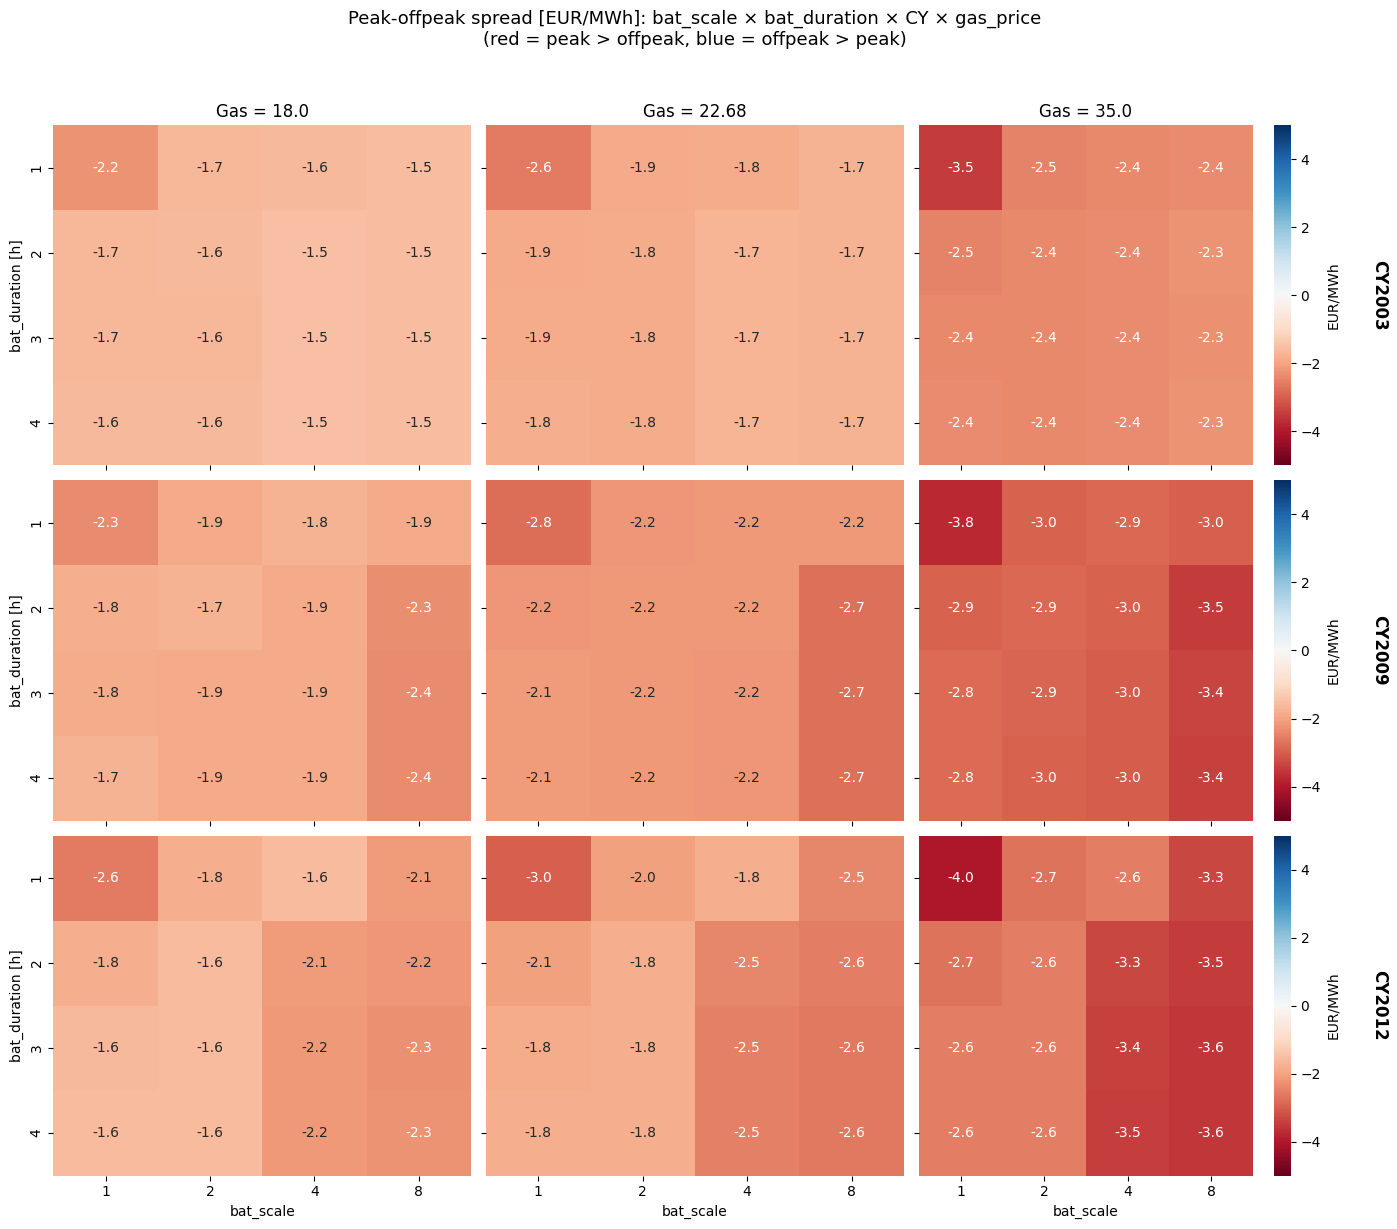

In [3]:
eu_spread = spread_df.groupby(["tag", "battery_scale", "battery_duration", "climate_year", "gas_price"])["spread"].median().reset_index()

# Heatmap: bat_scale × bat_duration, faceted by climate_year × gas_price
fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=True, sharey=True)

for row, cy in enumerate([2003, 2009, 2012]):
    for col, gp in enumerate([18.0, 22.68, 35.0]):
        ax = axes[row, col]
        sub = eu_spread[(eu_spread["climate_year"] == cy) & (eu_spread["gas_price"] == gp)]
        pivot = sub.groupby(["battery_duration", "battery_scale"])["spread"].median().reset_index()
        hm = pivot.pivot(index="battery_duration", columns="battery_scale", values="spread")

        sns.heatmap(hm, annot=True, fmt=".1f", cmap="RdBu", center=0, ax=ax,
                    cbar=col == 2, vmin=-5, vmax=5,
                    cbar_kws={"label": "EUR/MWh"} if col == 2 else {})
        ax.set_xlabel("bat_scale" if row == 2 else "")
        ax.set_ylabel("bat_duration [h]" if col == 0 else "")

        if row == 0:
            ax.set_title(f"Gas = {gp}")
        if col == 2:
            ax.yaxis.set_label_position("right")
            ax.text(1.35, 0.5, f"CY{cy}", transform=ax.transAxes,
                    rotation=-90, va="center", fontsize=12, fontweight="bold")

plt.suptitle("Peak-offpeak spread [EUR/MWh]: bat_scale \u00d7 bat_duration \u00d7 CY \u00d7 gas_price\n(red = peak > offpeak, blue = offpeak > peak)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
# Export for thesis
fig.savefig("../tukedip_pdflatex_utf-8/figures/fig_spread_heatmap.jpg", dpi=200, bbox_inches="tight")
print("Saved fig_spread_heatmap.jpg")

Saved fig_spread_heatmap.jpg


### Seasonal breakdown of peak-offpeak spread

Same metric (peak − offpeak) but split by season: Spring (Mar–May), Summer (Jun–Aug), Autumn (Sep–Nov), Winter (Dec–Feb). Fixed gas=22.68, co2=113.4, dur=1× — varying bat_scale and climate year.

  Processed 100/432...
  Processed 200/432...
  Processed 300/432...
  Processed 400/432...
Seasonal spread data: 1728 rows


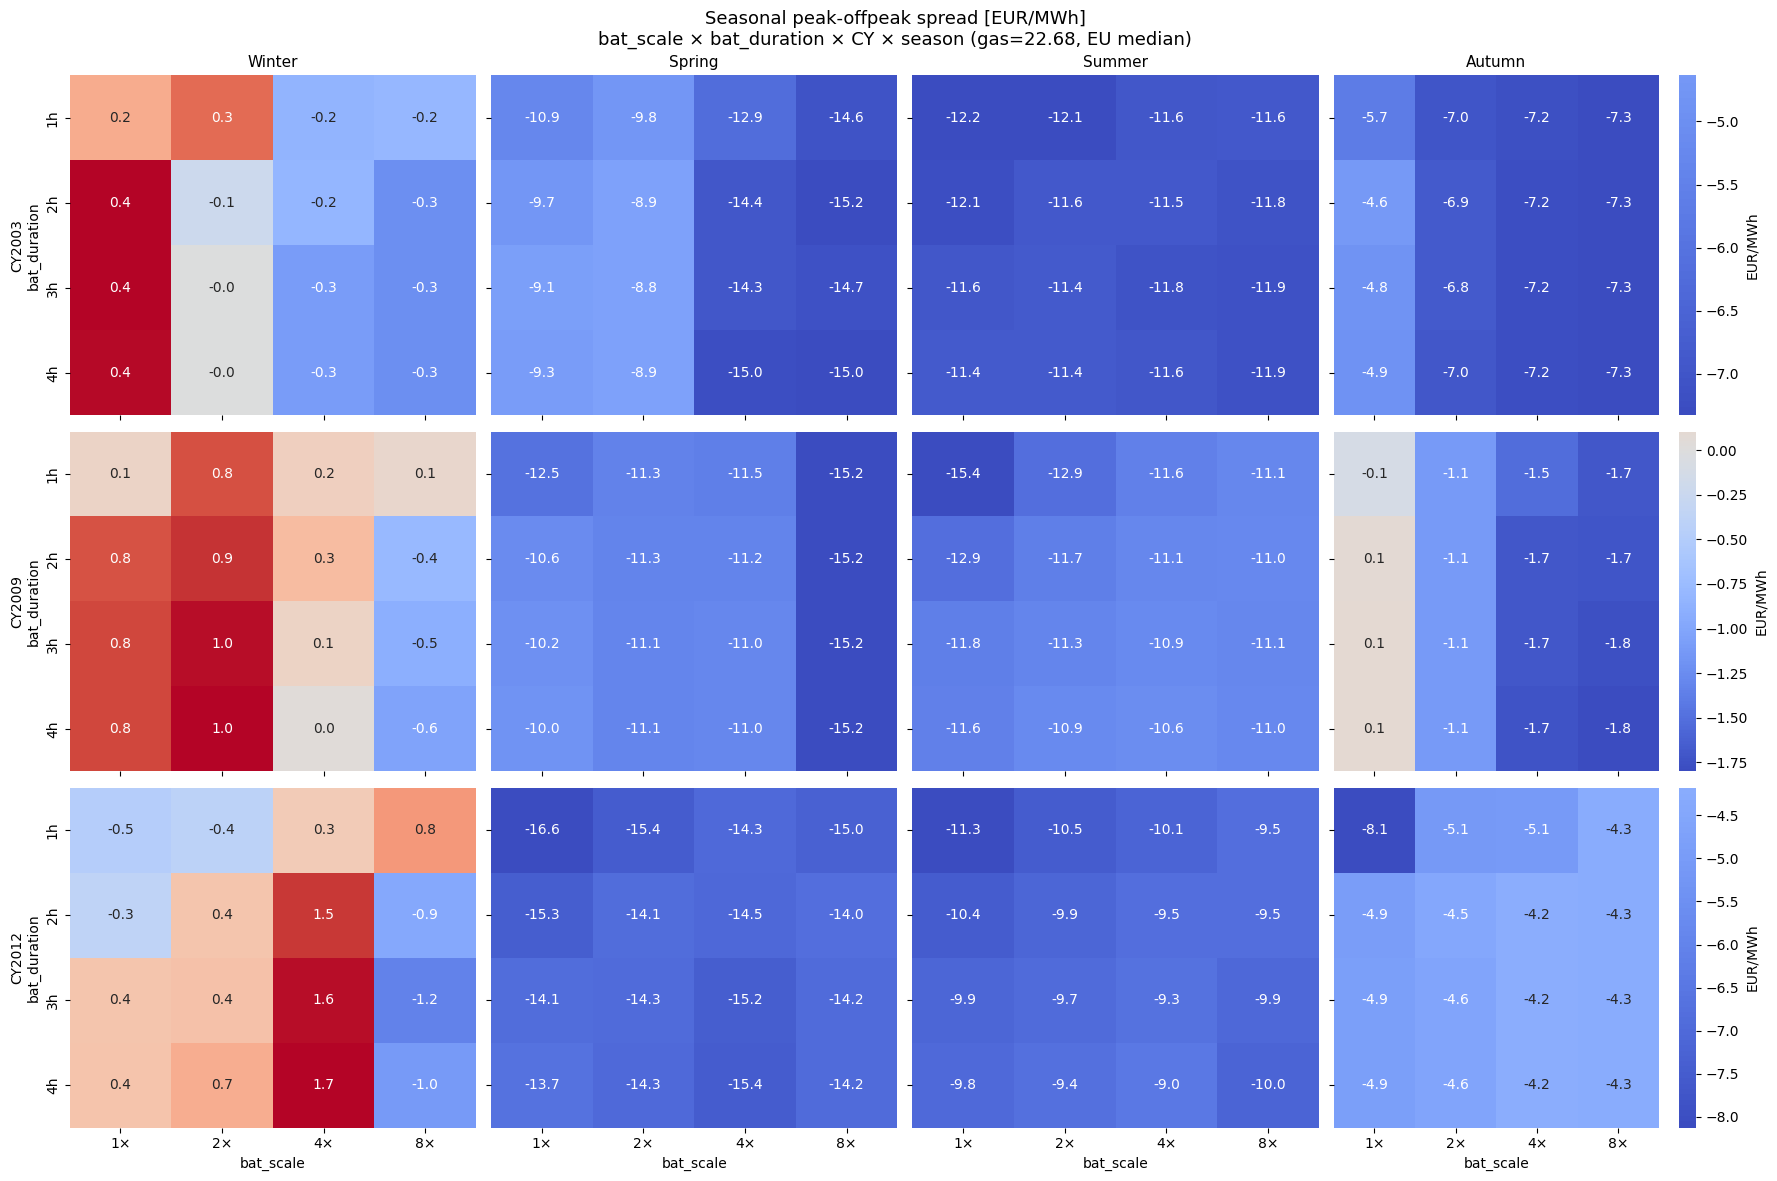

In [5]:
# Seasonal peak-offpeak spread — heatmap with bat_scale × bat_duration
def get_season(month):
    if month in (3, 4, 5): return "Spring"
    if month in (6, 7, 8): return "Summer"
    if month in (9, 10, 11): return "Autumn"
    return "Winter"

lmp_all["season"] = lmp_all["timestamp"].dt.month.map(get_season)

# Use all scenarios (all gas/co2/dur combinations), compute spread per scenario
seasonal_records = []
for i, row in enumerate(results.itertuples()):
    lmp_tag = lmp_all[lmp_all["tag"] == row.tag]
    for season in ["Winter", "Spring", "Summer", "Autumn"]:
        lmp_s = lmp_tag[lmp_tag["season"] == season]
        if len(lmp_s) == 0:
            continue
        peak = lmp_s[lmp_s["is_peak"]][bus_cols].mean().median()
        offpeak = lmp_s[~lmp_s["is_peak"]][bus_cols].mean().median()
        seasonal_records.append({
            "tag": row.tag,
            "bat_scale": row.battery_scale,
            "bat_duration": row.battery_duration,
            "climate_year": row.climate_year,
            "gas_price": row.gas_price,
            "season": season,
            "spread": peak - offpeak,
        })
    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/432...")

seas_df = pd.DataFrame(seasonal_records)
print(f"Seasonal spread data: {len(seas_df)} rows")

# Heatmap: 3 rows (CY) × 4 cols (season), bat_scale × bat_duration inside
# Fixed gas=22.68, co2=113.4
FIX_GAS, FIX_CO2 = 22.68, 113.4
season_order = ["Winter", "Spring", "Summer", "Autumn"]
cy_list = [2003, 2009, 2012]

fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharex=True, sharey=True)

# Compute global color range
sub_all = seas_df[(seas_df["gas_price"] == FIX_GAS)]
vmin = sub_all.groupby(["climate_year", "season", "bat_scale", "bat_duration"])["spread"].median().min()
vmax = sub_all.groupby(["climate_year", "season", "bat_scale", "bat_duration"])["spread"].median().max()

for row, cy in enumerate(cy_list):
    for col, season in enumerate(season_order):
        ax = axes[row, col]
        sub = seas_df[(seas_df["climate_year"] == cy) & (seas_df["season"] == season) &
                      (seas_df["gas_price"] == FIX_GAS)]
        pivot = sub.groupby(["bat_duration", "bat_scale"])["spread"].median().reset_index()
        hm = pivot.pivot(index="bat_duration", columns="bat_scale", values="spread")
        hm = hm.reindex(index=[1, 2, 3, 4], columns=[1, 2, 4, 8])

        import seaborn as sns
        sns.heatmap(hm, annot=True, fmt=".1f", cmap="coolwarm", ax=ax,
                    center=0, 
                    cbar=(col == 3),
                    cbar_kws={"label": "EUR/MWh"} if col == 3 else {},
                    xticklabels=[f"{s}×" for s in [1, 2, 4, 8]],
                    yticklabels=[f"{d}h" for d in [1, 2, 3, 4]])
        ax.set_xlabel("bat_scale" if row == 2 else "")
        ax.set_ylabel(f"CY{cy}\nbat_duration" if col == 0 else "")
        if row == 0:
            ax.set_title(season, fontsize=11)

fig.suptitle("Seasonal peak-offpeak spread [EUR/MWh]\nbat_scale × bat_duration × CY × season (gas=22.68, EU median)",
             fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
# Export for thesis
fig.savefig("../tukedip_pdflatex_utf-8/figures/fig_seasonal_spread.jpg", dpi=200, bbox_inches="tight")
print("Saved fig_seasonal_spread.jpg")

Saved fig_seasonal_spread.jpg


Profile records: 1152


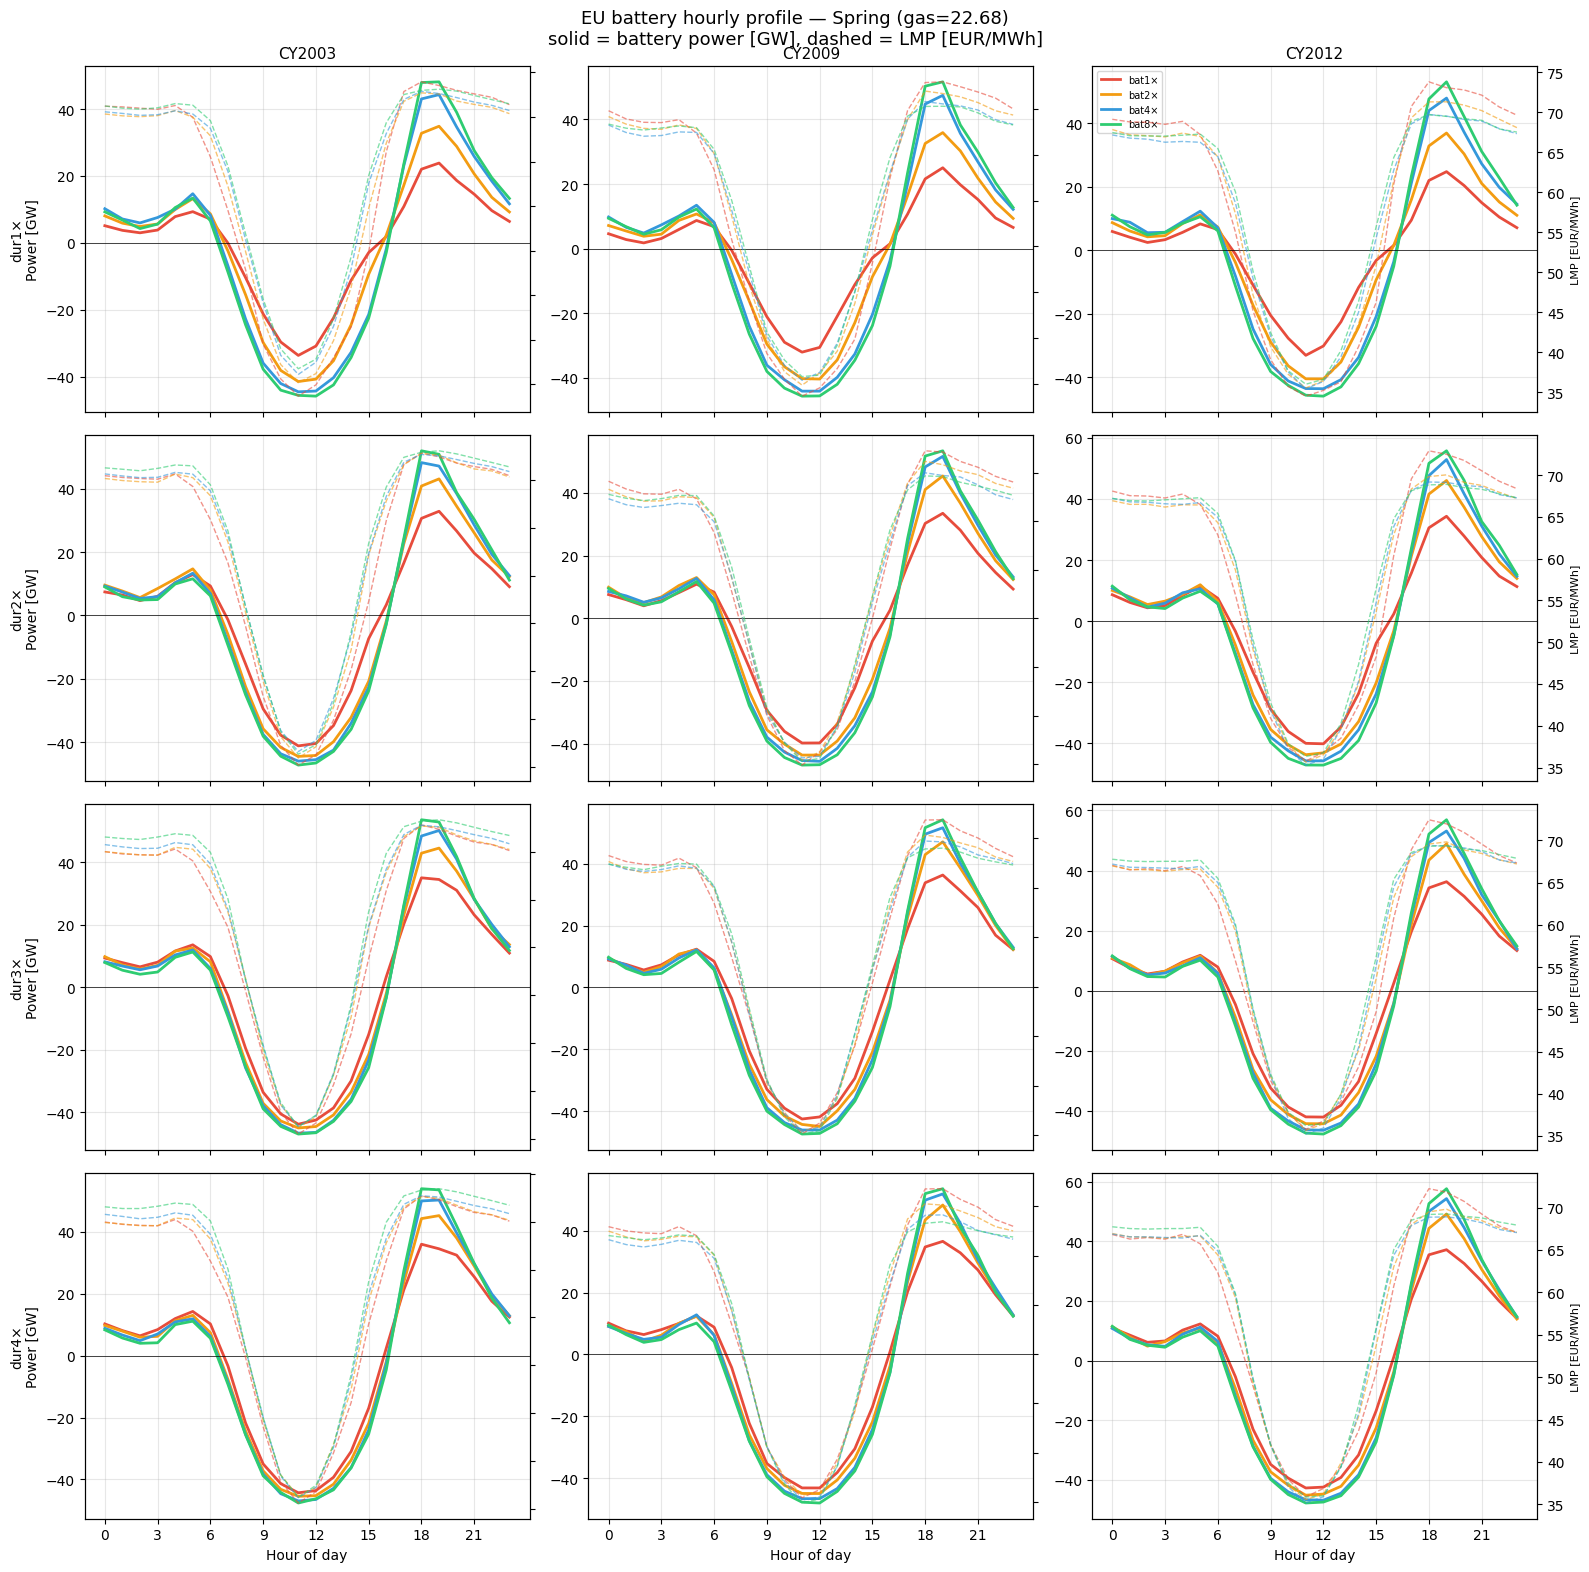

In [7]:
# Hourly battery profile + LMP overlay — Spring, bat_scale × bat_duration
# Fixed: gas=22.68, co2=113.4

FIX_GAS_P, FIX_CO2_P = 22.68, 113.4
scale_colors = {1: "#e74c3c", 2: "#f39c12", 4: "#3498db", 8: "#2ecc71"}
cy_list = [2003, 2009, 2012]
dur_list = [1, 2, 3, 4]

# Get battery columns
bat_units_p = static_su[static_su["carrier"] == "battery"].index.tolist()
bat_cols_p = [c for c in stor_cols if c in bat_units_p]

# Filter relevant scenarios
rel_tags = results[
    (results["gas_price"] == FIX_GAS_P) &
    (results["co2_price"] == FIX_CO2_P)
][["tag", "battery_scale", "battery_duration", "climate_year"]]

# Compute hourly EU battery power + LMP — Spring only
profiles = []
for _, row in rel_tags.iterrows():
    # Battery power
    stor_tag = stor_p_all[stor_p_all["tag"] == row["tag"]]
    bat_power = stor_tag[bat_cols_p].sum(axis=1) / 1e3  # GW
    ts = pd.to_datetime(stor_tag["timestamp"])
    spring_mask = ts.dt.month.isin([3, 4, 5])
    if spring_mask.sum() == 0:
        continue
    hour = ts.dt.hour

    # LMP (EU median)
    lmp_tag = lmp_all[lmp_all["tag"] == row["tag"]]
    lmp_eu = lmp_tag[bus_cols].median(axis=1)
    lmp_ts = pd.to_datetime(lmp_tag["timestamp"])
    lmp_spring = lmp_ts.dt.month.isin([3, 4, 5])

    hourly_power = bat_power[spring_mask.values].groupby(hour[spring_mask].values).mean()
    hourly_lmp = lmp_eu[lmp_spring.values].groupby(lmp_ts.dt.hour[lmp_spring].values).mean()

    for h in range(24):
        profiles.append({
            "climate_year": row["climate_year"],
            "bat_scale": row["battery_scale"],
            "bat_duration": row["battery_duration"],
            "hour": h,
            "power_gw": hourly_power.get(h, 0),
            "lmp_eur": hourly_lmp.get(h, 0),
        })

prof_df = pd.DataFrame(profiles)
print(f"Profile records: {len(prof_df)}")

# Plot: 4 rows (dur) × 3 cols (CY)
fig, axes = plt.subplots(4, 3, figsize=(16, 16), sharex=True)

for row_idx, dur in enumerate(dur_list):
    for col_idx, cy in enumerate(cy_list):
        ax = axes[row_idx, col_idx]
        ax2 = ax.twinx()

        for bs in [1, 2, 4, 8]:
            sub = prof_df[(prof_df["climate_year"] == cy) &
                          (prof_df["bat_scale"] == bs) &
                          (prof_df["bat_duration"] == dur)].sort_values("hour")
            if len(sub) == 0:
                continue
            ax.plot(sub["hour"], sub["power_gw"], color=scale_colors[bs],
                    linewidth=2, label=f"bat{bs}×")
            ax2.plot(sub["hour"], sub["lmp_eur"], color=scale_colors[bs],
                     linewidth=1, linestyle="--", alpha=0.6)

        ax.axhline(0, color="black", linewidth=0.5)
        ax.grid(alpha=0.3)
        ax.set_xticks(range(0, 24, 3))

        if row_idx == 0:
            ax.set_title(f"CY{cy}", fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"dur{dur}×\nPower [GW]")
        if col_idx == 2:
            ax2.set_ylabel("LMP [EUR/MWh]", fontsize=8)
        else:
            ax2.set_yticklabels([])
        if row_idx == 3:
            ax.set_xlabel("Hour of day")
        if row_idx == 0 and col_idx == 2:
            ax.legend(fontsize=7, loc="upper left")

fig.suptitle("EU battery hourly profile — Spring (gas=22.68)\n"
             "solid = battery power [GW], dashed = LMP [EUR/MWh]",
             fontsize=13)
plt.tight_layout()
plt.show()

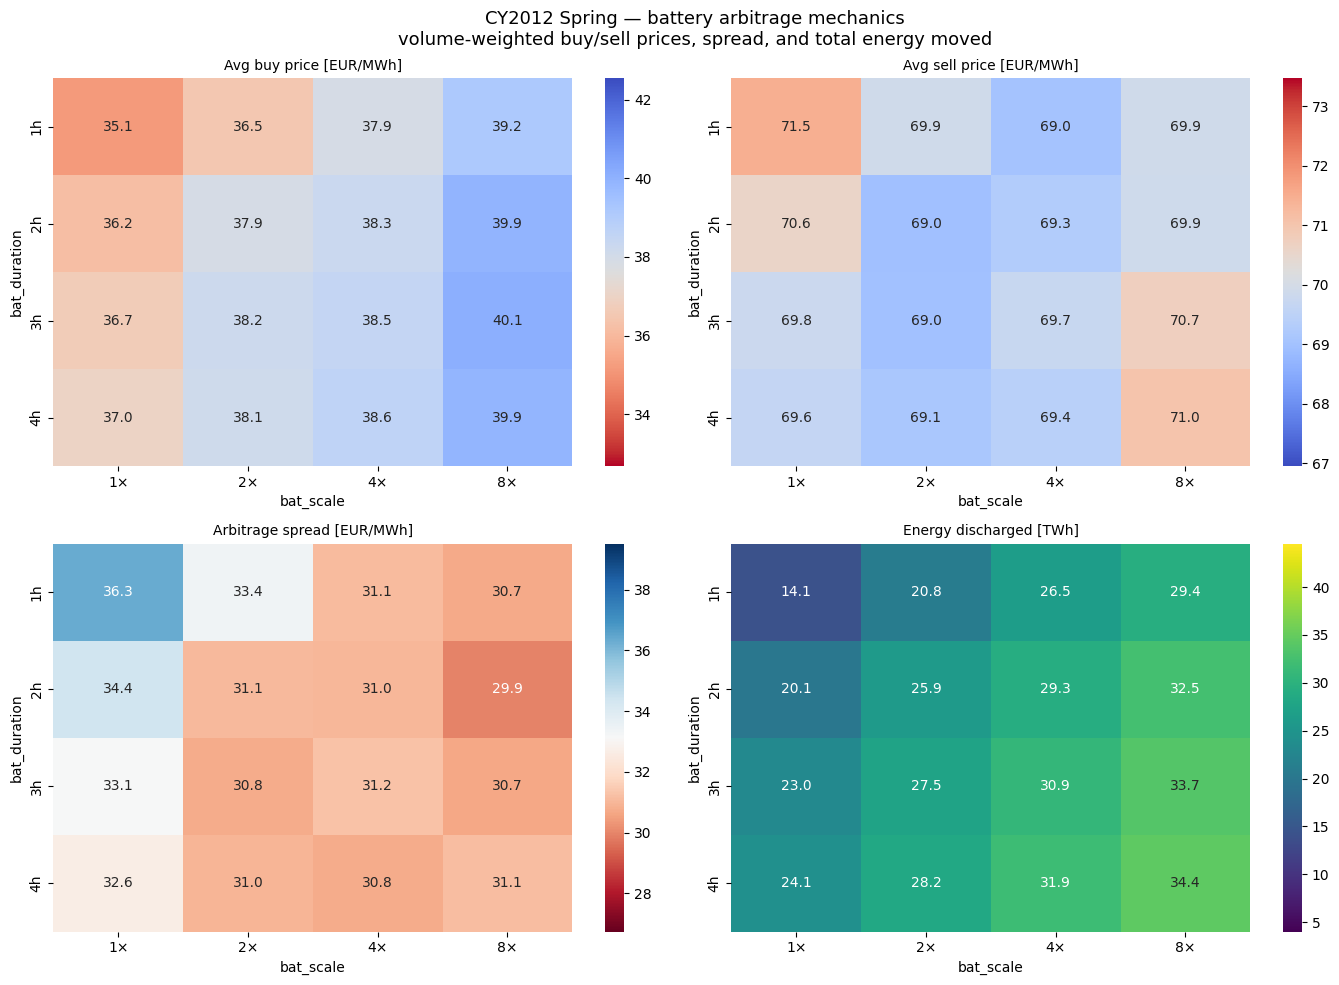

In [8]:
# Battery arbitrage summary: buy price, sell price, spread, volume
# CY2012 Spring, all bat_scale × bat_duration

FIX_GAS_M, FIX_CO2_M, FIX_CY_M = 22.68, 113.4, 2012
scale_list = [1, 2, 4, 8]
dur_list_m = [1, 2, 3, 4]

bat_units_m = static_su[static_su["carrier"] == "battery"].index.tolist()
bat_cols_m = [c for c in stor_cols if c in bat_units_m]

records = []
for bs in scale_list:
    for dur in dur_list_m:
        tag_row = results[
            (results["battery_scale"] == bs) &
            (results["battery_duration"] == dur) &
            (results["gas_price"] == FIX_GAS_M) &
            (results["co2_price"] == FIX_CO2_M) &
            (results["climate_year"] == FIX_CY_M)
        ]
        if len(tag_row) == 0:
            continue
        tag = tag_row["tag"].values[0]

        stor_tag = stor_p_all[stor_p_all["tag"] == tag]
        bat_power = stor_tag[bat_cols_m].sum(axis=1).values  # MW
        ts = pd.to_datetime(stor_tag["timestamp"].values)

        lmp_tag = lmp_all[lmp_all["tag"] == tag]
        lmp_eu = lmp_tag[bus_cols].median(axis=1).values

        spring_s = ts.month.isin([3, 4, 5])
        power = bat_power[spring_s]
        lmp = lmp_eu[spring_s]

        charge_mask = power < 0
        discharge_mask = power > 0

        charge_mwh = abs(power[charge_mask].sum())  # total MWh charged
        discharge_mwh = power[discharge_mask].sum()  # total MWh discharged
        avg_buy = (lmp[charge_mask] * abs(power[charge_mask])).sum() / charge_mwh if charge_mwh > 0 else 0
        avg_sell = (lmp[discharge_mask] * power[discharge_mask]).sum() / discharge_mwh if discharge_mwh > 0 else 0

        records.append({
            "bat_scale": bs, "bat_duration": dur,
            "avg_buy": avg_buy, "avg_sell": avg_sell,
            "spread": avg_sell - avg_buy,
            "charged_twh": charge_mwh / 1e6,
            "discharged_twh": discharge_mwh / 1e6,
        })

arb_df = pd.DataFrame(records)

# 4 heatmaps: buy price, sell price, spread, discharged volume
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
import seaborn as sns

metrics = [
    ("avg_buy", "Avg buy price [EUR/MWh]", "coolwarm_r", None),
    ("avg_sell", "Avg sell price [EUR/MWh]", "coolwarm", None),
    ("spread", "Arbitrage spread [EUR/MWh]", "RdBu", None),
    ("discharged_twh", "Energy discharged [TWh]", "viridis", None),
]

for ax, (col, title, cmap_name, center) in zip(axes.flatten(), metrics):
    pivot = arb_df.pivot(index="bat_duration", columns="bat_scale", values=col)
    pivot = pivot.reindex(index=[1, 2, 3, 4], columns=[1, 2, 4, 8])
    data_range = pivot.max().max() - pivot.min().min()
    pad = max(data_range * 0.5, 2)  # at least 2 EUR padding on each side
    v_min = pivot.min().min() - pad
    v_max = pivot.max().max() + pad
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap=cmap_name, ax=ax, linewidths=0,
                vmin=v_min, vmax=v_max,
                xticklabels=[f"{s}×" for s in [1, 2, 4, 8]],
                yticklabels=[f"{d}h" for d in [1, 2, 3, 4]])
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("bat_scale")
    ax.set_ylabel("bat_duration")

fig.suptitle("CY2012 Spring — battery arbitrage mechanics\n"
             "volume-weighted buy/sell prices, spread, and total energy moved",
             fontsize=13)
plt.tight_layout()
plt.show()

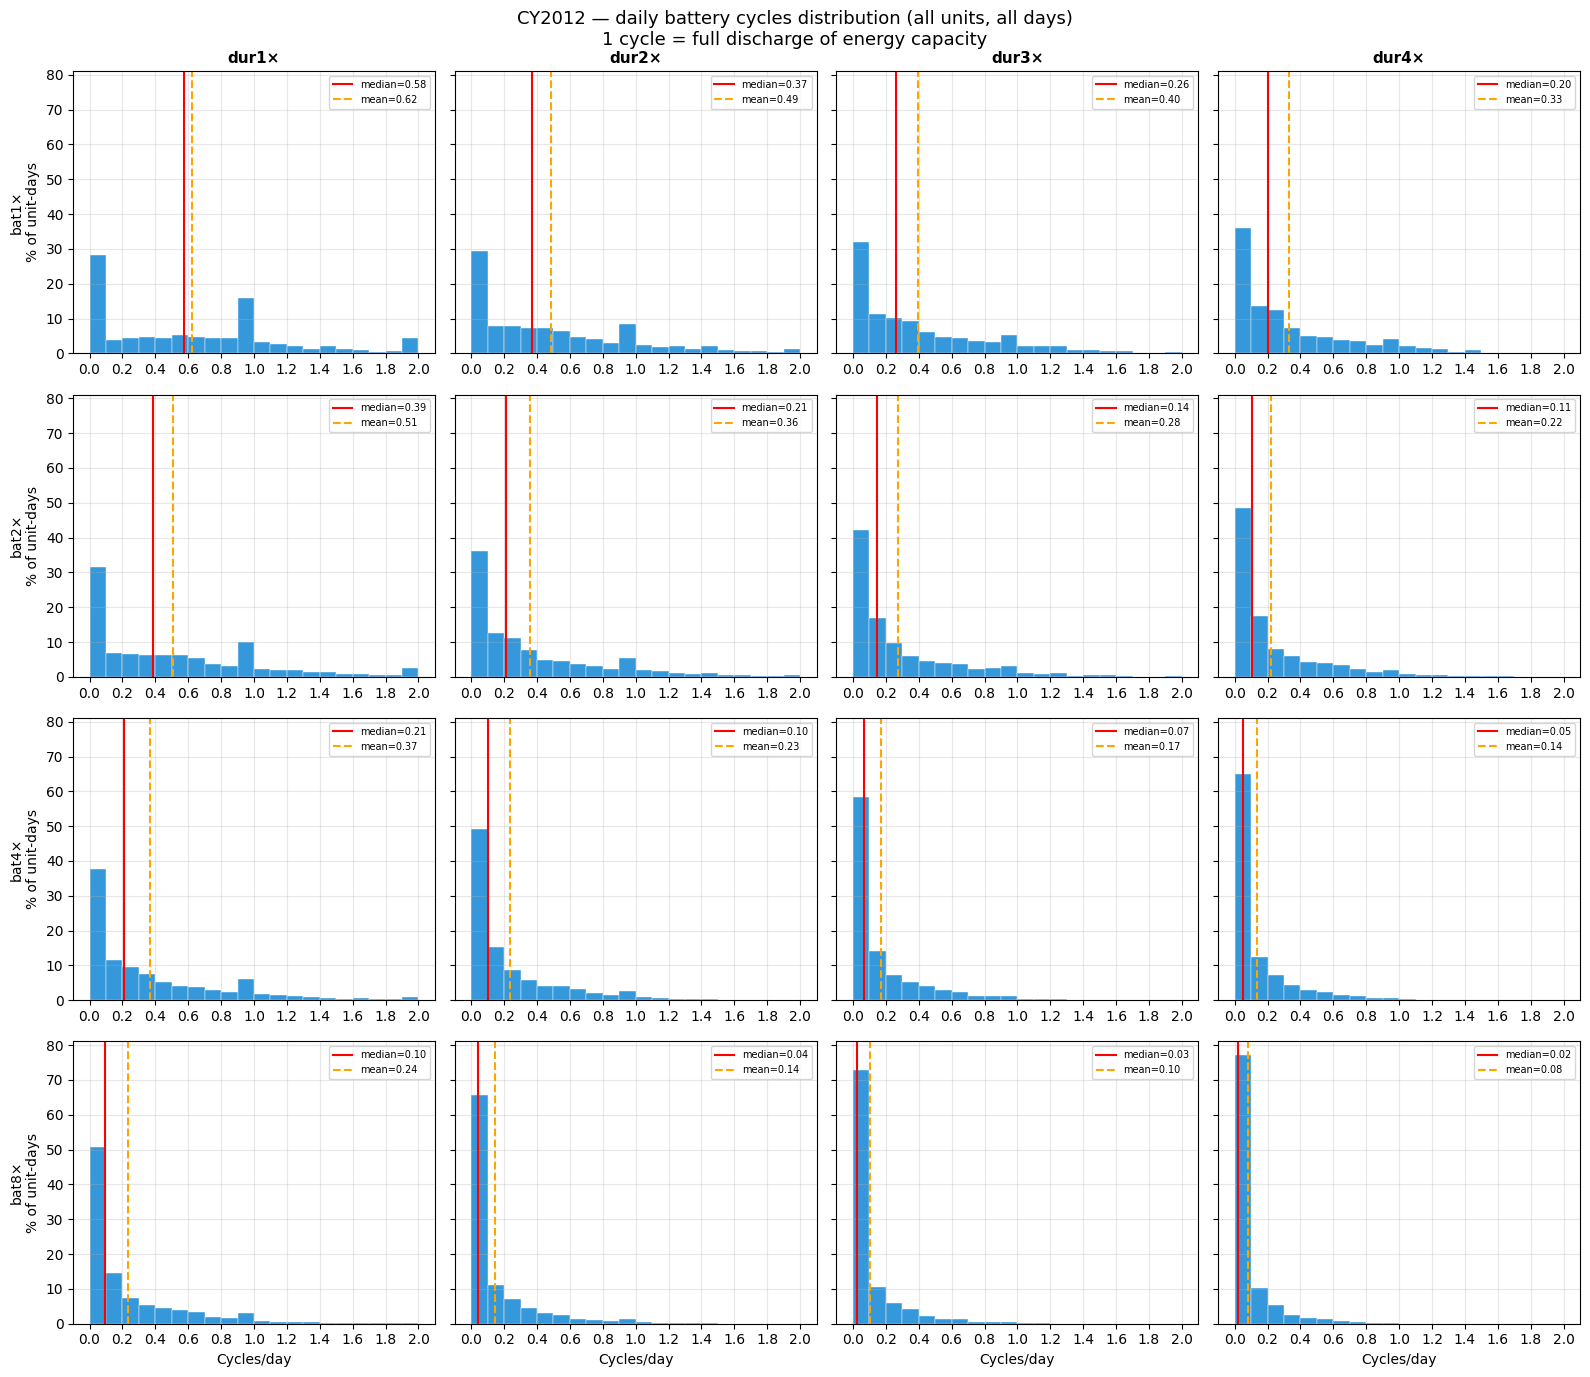

In [9]:
# Daily cycles per battery unit — CY2012, gas=22.68, co2=113.4
# Cycle = full discharge (total daily discharged energy / energy capacity)

FIX_GAS_C, FIX_CO2_C, FIX_CY_C = 22.68, 113.4, 2012

bat_units_c = static_su[static_su["carrier"] == "battery"]
bat_cols_c = [c for c in stor_cols if c in bat_units_c.index]

# Get p_nom and max_hours per battery unit (from static data)
bat_info = bat_units_c.loc[bat_cols_c, ["bus", "p_nom", "max_hours"]].copy()
bat_info["e_nom"] = bat_info["p_nom"] * bat_info["max_hours"]

fig, axes = plt.subplots(4, 4, figsize=(16, 14), sharey=True)

for row_idx, bs in enumerate([1, 2, 4, 8]):
    for col_idx, dur in enumerate([1, 2, 3, 4]):
        ax = axes[row_idx, col_idx]
        
        tag_row = results[
            (results["battery_scale"] == bs) &
            (results["battery_duration"] == dur) &
            (results["gas_price"] == FIX_GAS_C) &
            (results["co2_price"] == FIX_CO2_C) &
            (results["climate_year"] == FIX_CY_C)
        ]
        if len(tag_row) == 0:
            ax.set_visible(False)
            continue
        tag = tag_row["tag"].values[0]
        
        stor_tag = stor_p_all[stor_p_all["tag"] == tag]
        ts = pd.to_datetime(stor_tag["timestamp"].values)
        
        # Per unit, per day: cycles = total discharged MWh / (p_nom * bat_scale * max_hours * dur)
        all_daily_cycles = []
        for unit in bat_cols_c:
            power = stor_tag[unit].values
            discharge = np.where(power > 0, power, 0)
            e_cap = bat_info.loc[unit, "p_nom"] * bs * bat_info.loc[unit, "max_hours"] * dur
            if e_cap <= 0:
                continue
            # Group by day
            days = ts.date
            df_day = pd.DataFrame({"day": days, "discharge": discharge})
            daily_dis = df_day.groupby("day")["discharge"].sum()
            daily_cycles = daily_dis / e_cap
            all_daily_cycles.extend(daily_cycles.values)
        
        all_daily_cycles = np.array(all_daily_cycles)
        
        ax.hist(all_daily_cycles, bins=np.arange(0, 2.05, 0.1), color="#3498db",
                edgecolor="white", linewidth=0.3, weights=np.ones_like(all_daily_cycles)/len(all_daily_cycles)*100)
        ax.axvline(np.median(all_daily_cycles), color="red", linewidth=1.5, 
                   label=f"median={np.median(all_daily_cycles):.2f}")
        ax.axvline(np.mean(all_daily_cycles), color="orange", linewidth=1.5, linestyle="--",
                   label=f"mean={np.mean(all_daily_cycles):.2f}")
        
        if row_idx == 0:
            ax.set_title(f"dur{dur}×", fontsize=11, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(f"bat{bs}×\n% of unit-days")
        if row_idx == 3:
            ax.set_xlabel("Cycles/day")
        ax.legend(fontsize=7)
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))
        ax.grid(alpha=0.3)

fig.suptitle("CY2012 — daily battery cycles distribution (all units, all days)\n"
             "1 cycle = full discharge of energy capacity",
             fontsize=13)
plt.tight_layout()
plt.show()

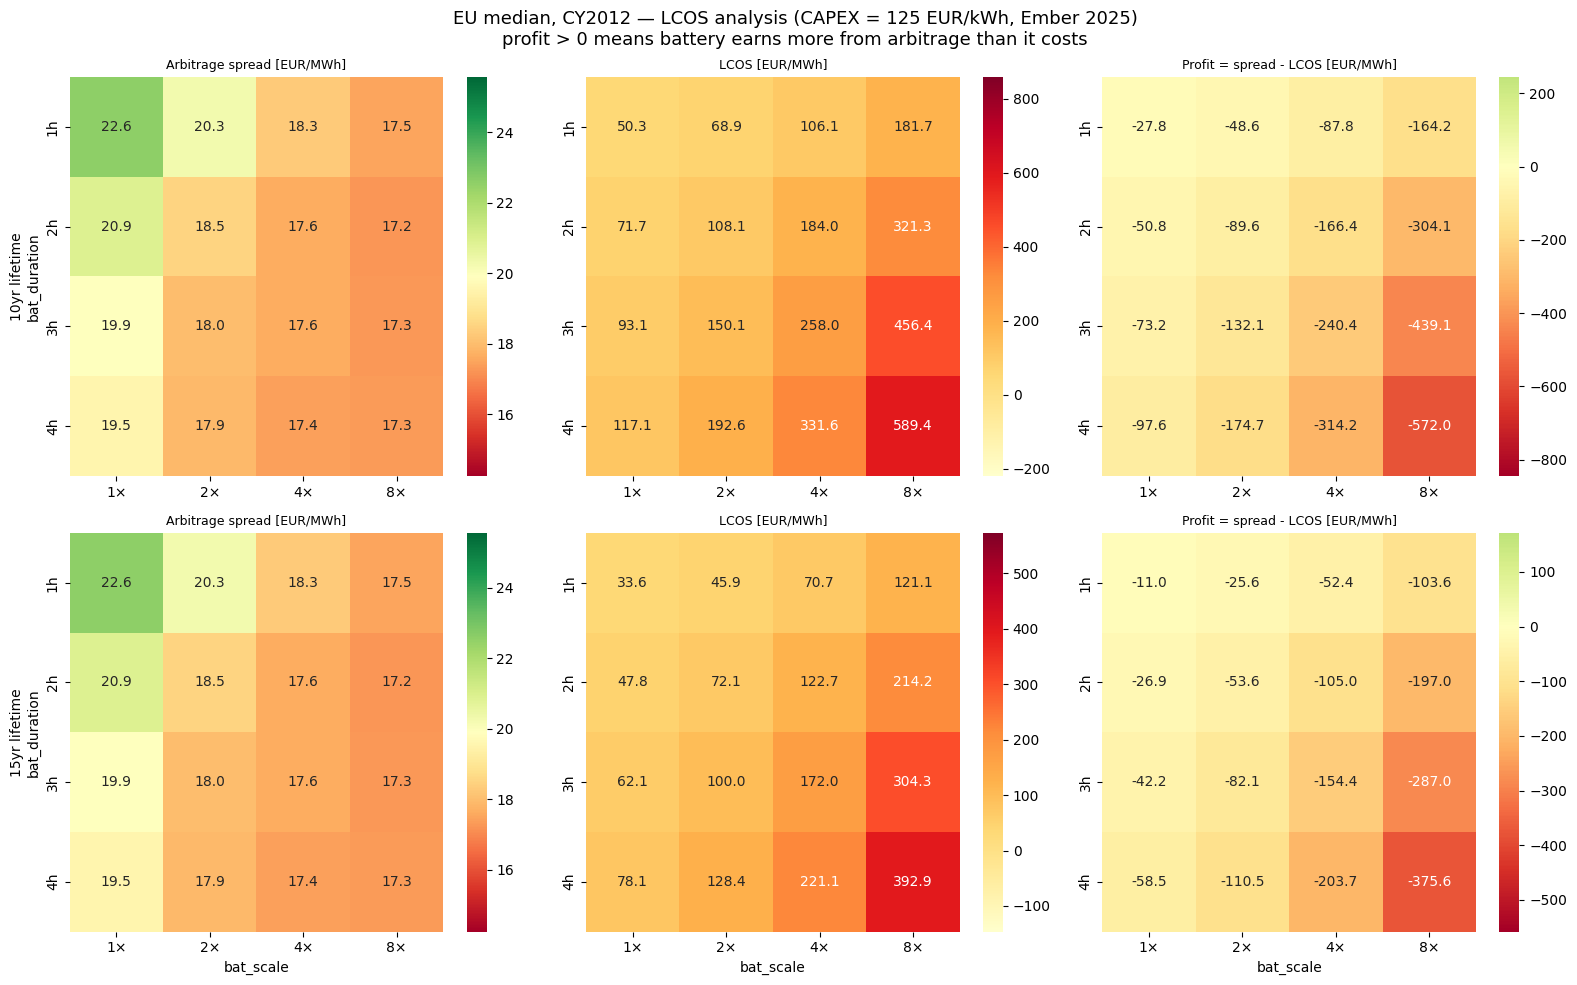


LCOS summary (CAPEX = 125 EUR/kWh)

  Lifetime = 10 years:
    bat1× dur1h: cycles=248/yr, spread=22.6, LCOS=50.3, profit=-27.8 ✗
    bat1× dur2h: cycles=174/yr, spread=20.9, LCOS=71.7, profit=-50.8 ✗
    bat1× dur3h: cycles=134/yr, spread=19.9, LCOS=93.1, profit=-73.2 ✗
    bat1× dur4h: cycles=107/yr, spread=19.5, LCOS=117.1, profit=-97.6 ✗
    bat2× dur1h: cycles=182/yr, spread=20.3, LCOS=68.9, profit=-48.6 ✗
    bat2× dur2h: cycles=116/yr, spread=18.5, LCOS=108.1, profit=-89.6 ✗
    bat2× dur3h: cycles=83/yr, spread=18.0, LCOS=150.1, profit=-132.1 ✗
    bat2× dur4h: cycles=65/yr, spread=17.9, LCOS=192.6, profit=-174.7 ✗
    bat4× dur1h: cycles=118/yr, spread=18.3, LCOS=106.1, profit=-87.8 ✗
    bat4× dur2h: cycles=68/yr, spread=17.6, LCOS=184.0, profit=-166.4 ✗
    bat4× dur3h: cycles=48/yr, spread=17.6, LCOS=258.0, profit=-240.4 ✗
    bat4× dur4h: cycles=38/yr, spread=17.4, LCOS=331.6, profit=-314.2 ✗
    bat8× dur1h: cycles=69/yr, spread=17.5, LCOS=181.7, profit=-164.2 ✗
    bat8

In [10]:
# LCOS vs arbitrage spread — is battery storage profitable?
# CAPEX: 125 EUR/kWh (Ember 2025, utility-scale 4h+ all-in)
# Lifetime: 10 and 15 years
# LCOS = CAPEX / (cycles_per_day * 365 * lifetime)
# Profit = spread - LCOS

CAPEX_KWHR = 125  # EUR/kWh (Ember 2025)
LIFETIMES = [10, 15]

# Reuse arb_df from mechanism cell (has spread, avg cycles per combo)
# Recompute with cycles info for all bat_scale × bat_duration

FIX_GAS_L, FIX_CO2_L, FIX_CY_L = 22.68, 113.4, 2012
bat_units_l = static_su[static_su["carrier"] == "battery"]
bat_cols_l = [c for c in stor_cols if c in bat_units_l.index]
bat_info_l = bat_units_l.loc[bat_cols_l, ["p_nom", "max_hours"]].copy()

lcos_records = []
for bs in [1, 2, 4, 8]:
    for dur in [1, 2, 3, 4]:
        tag_row = results[
            (results["battery_scale"] == bs) &
            (results["battery_duration"] == dur) &
            (results["gas_price"] == FIX_GAS_L) &
            (results["co2_price"] == FIX_CO2_L) &
            (results["climate_year"] == FIX_CY_L)
        ]
        if len(tag_row) == 0:
            continue
        tag = tag_row["tag"].values[0]

        stor_tag = stor_p_all[stor_p_all["tag"] == tag]
        ts = pd.to_datetime(stor_tag["timestamp"].values)
        
        lmp_tag = lmp_all[lmp_all["tag"] == tag]
        lmp_eu = lmp_tag[bus_cols].median(axis=1).values

        # Total annual cycles and spread (whole year, not just spring)
        total_discharge_mwh = 0
        total_e_cap_mwh = 0
        total_revenue = 0
        total_cost = 0
        total_dis_for_spread = 0
        total_ch_for_spread = 0

        for unit in bat_cols_l:
            power = stor_tag[unit].values
            e_cap = bat_info_l.loc[unit, "p_nom"] * bs * bat_info_l.loc[unit, "max_hours"] * dur
            if e_cap <= 0:
                continue

            discharge = np.where(power > 0, power, 0)
            charge = np.where(power < 0, -power, 0)

            total_discharge_mwh += discharge.sum()
            total_e_cap_mwh += e_cap

            # Volume-weighted prices
            total_revenue += (discharge * lmp_eu).sum()
            total_dis_for_spread += discharge.sum()
            total_cost += (charge * lmp_eu).sum()
            total_ch_for_spread += charge.sum()

        annual_cycles = total_discharge_mwh / total_e_cap_mwh if total_e_cap_mwh > 0 else 0
        avg_sell = total_revenue / total_dis_for_spread if total_dis_for_spread > 0 else 0
        avg_buy = total_cost / total_ch_for_spread if total_ch_for_spread > 0 else 0
        spread = avg_sell - avg_buy

        for lifetime in LIFETIMES:
            total_kwh_delivered = annual_cycles * 365 * lifetime  # per kWh capacity
            # But annual_cycles is already annual (8760h), so:
            total_cycles_lifetime = annual_cycles * lifetime
            lcos = CAPEX_KWHR / (total_cycles_lifetime / 1000) if total_cycles_lifetime > 0 else 999
            profit = spread - lcos

            lcos_records.append({
                "bat_scale": bs, "bat_duration": dur, "lifetime": lifetime,
                "annual_cycles": annual_cycles,
                "spread": spread, "lcos": lcos, "profit": profit,
                "avg_buy": avg_buy, "avg_sell": avg_sell,
            })

lcos_df = pd.DataFrame(lcos_records)

# Plot: 2 rows (lifetime) × 3 cols (spread, LCOS, profit)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
import seaborn as sns

for row_idx, lt in enumerate(LIFETIMES):
    sub = lcos_df[lcos_df["lifetime"] == lt]

    for col_idx, (col, title, cmap_name) in enumerate([
        ("spread", f"Arbitrage spread [EUR/MWh]", "RdYlGn"),
        ("lcos", f"LCOS [EUR/MWh]", "YlOrRd"),
        ("profit", f"Profit = spread - LCOS [EUR/MWh]", "RdYlGn"),
    ]):
        ax = axes[row_idx, col_idx]
        pivot = sub.pivot(index="bat_duration", columns="bat_scale", values=col)
        pivot = pivot.reindex(index=[1, 2, 3, 4], columns=[1, 2, 4, 8])

        data_range = pivot.max().max() - pivot.min().min()
        pad = max(data_range * 0.5, 3)
        v_min = pivot.min().min() - pad
        v_max = pivot.max().max() + pad

        center = 0 if col == "profit" else None
        sns.heatmap(pivot, annot=True, fmt=".1f", cmap=cmap_name, ax=ax,
                    linewidths=0, vmin=v_min, vmax=v_max, center=center,
                    xticklabels=[f"{s}×" for s in [1, 2, 4, 8]],
                    yticklabels=[f"{d}h" for d in [1, 2, 3, 4]])
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("bat_scale" if row_idx == 1 else "")
        if col_idx == 0:
            ax.set_ylabel(f"{lt}yr lifetime\nbat_duration")
        else:
            ax.set_ylabel("")

fig.suptitle(f"EU median, CY2012 — LCOS analysis (CAPEX = {CAPEX_KWHR} EUR/kWh, Ember 2025)\n"
             f"profit > 0 means battery earns more from arbitrage than it costs",
             fontsize=13)
plt.tight_layout()
plt.show()

# Print summary
print(f"\nLCOS summary (CAPEX = {CAPEX_KWHR} EUR/kWh)")
for lt in LIFETIMES:
    sub = lcos_df[lcos_df["lifetime"] == lt]
    print(f"\n  Lifetime = {lt} years:")
    for _, r in sub.iterrows():
        marker = "✓" if r["profit"] > 0 else "✗"
        print(f"    bat{r['bat_scale']:.0f}× dur{r['bat_duration']:.0f}h: "
              f"cycles={r['annual_cycles']:.0f}/yr, spread={r['spread']:.1f}, "
              f"LCOS={r['lcos']:.1f}, profit={r['profit']:.1f} {marker}")

In [11]:
# Export for thesis
fig.savefig("../tukedip_pdflatex_utf-8/figures/fig_lcos.jpg", dpi=200, bbox_inches="tight")
print("Saved fig_lcos.jpg")

Saved fig_lcos.jpg


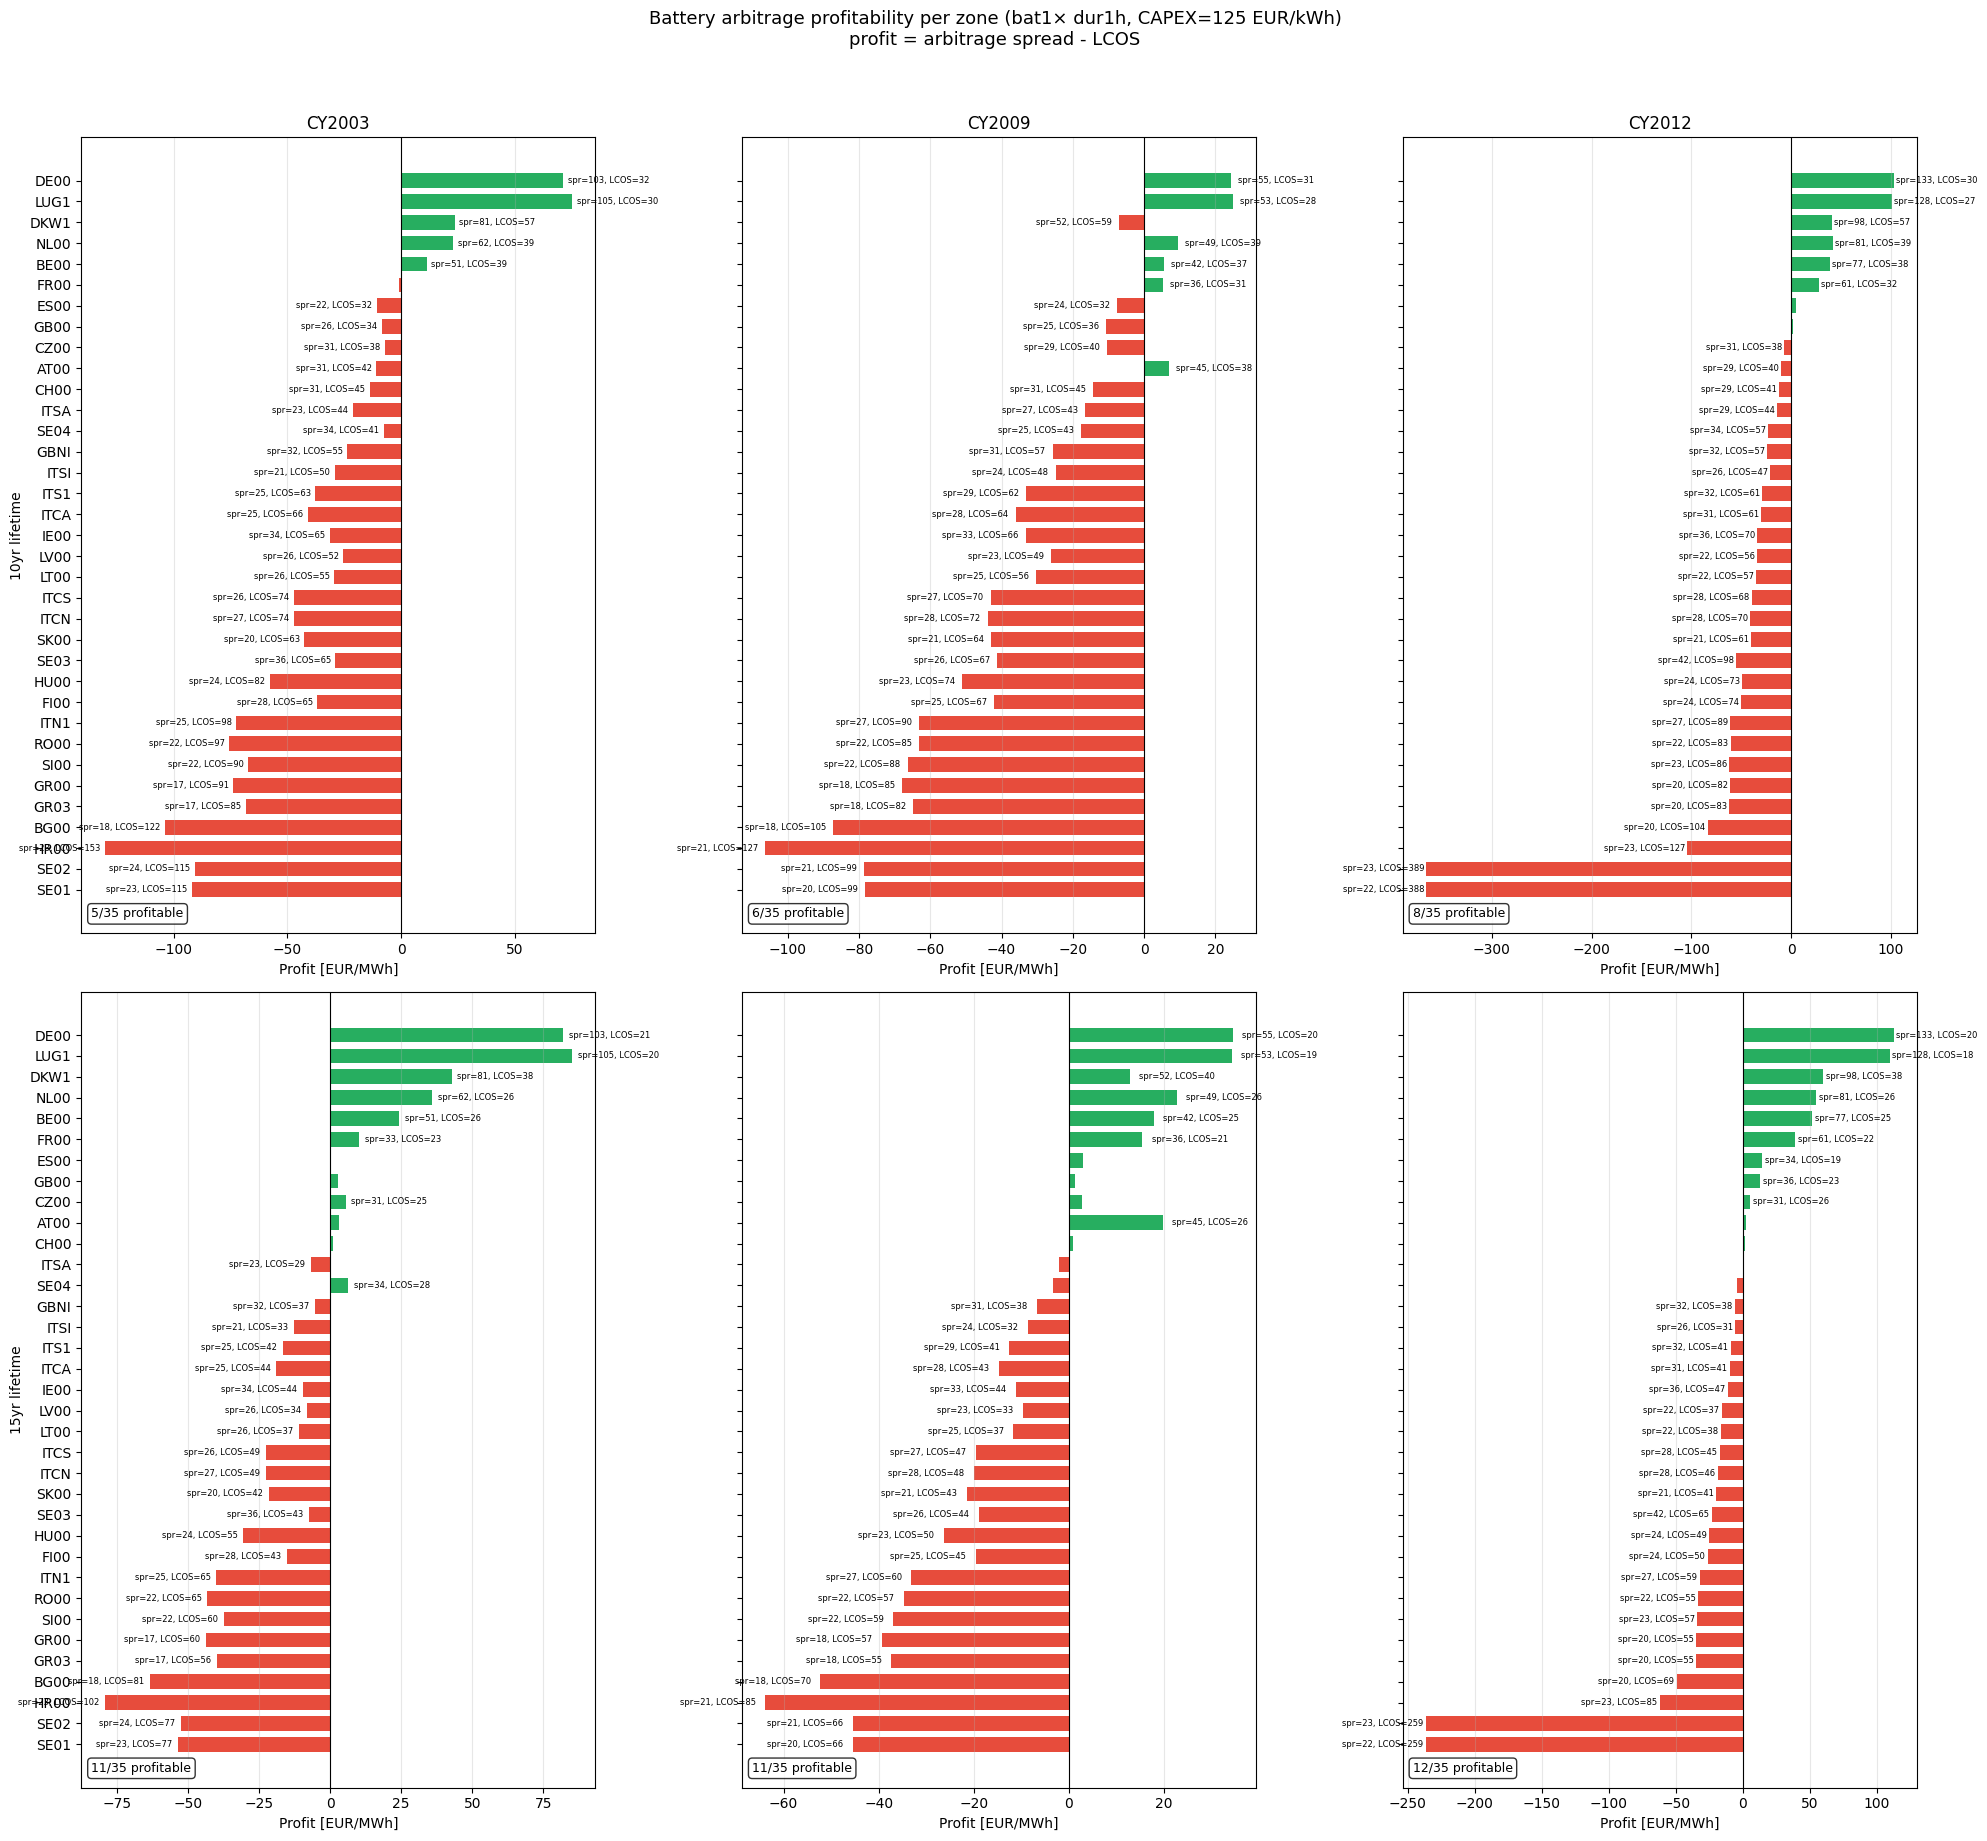

In [12]:
# LCOS profitability per zone — bat1× dur1h, all CYs, 15yr lifetime
CAPEX_C = 125  # EUR/kWh
FIX_BS_C, FIX_DUR_C = 1, 1
LIFETIMES_C = [10, 15]

bat_all = static_su[static_su["carrier"] == "battery"]
bat_cols_c = [c for c in stor_cols if c in bat_all.index]
bat_bus_map = bat_all.loc[bat_cols_c, "bus"]

zone_records = []
for cy in [2003, 2009, 2012]:
    tag_row = results[
        (results["battery_scale"] == FIX_BS_C) &
        (results["battery_duration"] == FIX_DUR_C) &
        (results["gas_price"] == 22.68) &
        (results["co2_price"] == 113.4) &
        (results["climate_year"] == cy)
    ]
    if len(tag_row) == 0:
        continue
    tag = tag_row["tag"].values[0]

    stor_tag = stor_p_all[stor_p_all["tag"] == tag]
    lmp_tag = lmp_all[lmp_all["tag"] == tag]

    for zone in sorted(bat_bus_map.unique()):
        zone_units = [c for c in bat_cols_c if bat_bus_map[c] == zone]
        if not zone_units or zone not in lmp_tag.columns:
            continue

        lmp_zone = lmp_tag[zone].values
        total_dis_mwh, total_e_cap = 0, 0
        total_rev, total_cost, total_dis, total_ch = 0, 0, 0, 0

        for unit in zone_units:
            power = stor_tag[unit].values
            e_cap = bat_all.loc[unit, "p_nom"] * FIX_BS_C * bat_all.loc[unit, "max_hours"] * FIX_DUR_C
            if e_cap <= 0:
                continue
            discharge = np.where(power > 0, power, 0)
            charge = np.where(power < 0, -power, 0)
            total_dis_mwh += discharge.sum()
            total_e_cap += e_cap
            total_rev += (discharge * lmp_zone).sum()
            total_dis += discharge.sum()
            total_cost += (charge * lmp_zone).sum()
            total_ch += charge.sum()

        if total_e_cap == 0 or total_dis == 0:
            continue

        annual_cycles = total_dis_mwh / total_e_cap
        spread = (total_rev / total_dis) - (total_cost / total_ch if total_ch > 0 else 0)
        for lt in LIFETIMES_C:
            lcos = CAPEX_C / (annual_cycles * lt / 1000)
            zone_records.append({
                "zone": zone, "climate_year": cy, "lifetime": lt,
                "spread": spread, "lcos": lcos, "profit": spread - lcos,
                "annual_cycles": annual_cycles,
            })

zone_df = pd.DataFrame(zone_records)

# Plot: 1 row × 3 cols (CY), sorted by CY2012 profit
fig, axes = plt.subplots(2, 3, figsize=(20, 18), sharey=True)

# Sort order from CY2012
sort_order = zone_df[(zone_df["climate_year"] == 2012) & (zone_df["lifetime"] == 15)].sort_values("profit", ascending=True)["zone"].tolist()

for row_idx, lt in enumerate(LIFETIMES_C):
  for col_idx, cy in enumerate([2003, 2009, 2012]):
    ax = axes[row_idx, col_idx]
    sub = zone_df[(zone_df["climate_year"] == cy) & (zone_df["lifetime"] == lt)].set_index("zone").reindex(sort_order).reset_index()
    sub = sub.dropna(subset=["profit"])

    colors = ["#27ae60" if p > 0 else "#e74c3c" for p in sub["profit"]]
    bars = ax.barh(sub["zone"], sub["profit"], color=colors, height=0.7)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Profit [EUR/MWh]")
    ax.set_title(f"CY{cy}" if row_idx == 0 else "", fontsize=12)
    if col_idx == 0:
        ax.set_ylabel(f"{lt}yr lifetime")
    ax.grid(axis="x", alpha=0.3)

    # Annotate only profitable zones
    for _, r in sub.iterrows():
        if abs(r["profit"]) > 5:
            x_pos = r["profit"] + (2 if r["profit"] > 0 else -2)
            ha = "left" if r["profit"] > 0 else "right"
            ax.text(x_pos, r["zone"], f"spr={r['spread']:.0f}, LCOS={r['lcos']:.0f}", va="center", ha=ha, fontsize=6)

    n_pos = (sub["profit"] > 0).sum()
    ax.text(0.02, 0.02, f"{n_pos}/{len(sub)} profitable", transform=ax.transAxes,
            fontsize=9, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

fig.suptitle(f"Battery arbitrage profitability per zone (bat1× dur1h, CAPEX={CAPEX_C} EUR/kWh)\n"
             f"profit = arbitrage spread - LCOS",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

  Done bat1× dur1×
  Done bat1× dur2×
  Done bat1× dur3×
  Done bat1× dur4×
  Done bat2× dur1×
  Done bat2× dur2×
  Done bat2× dur3×
  Done bat2× dur4×
  Done bat4× dur1×
  Done bat4× dur2×
  Done bat4× dur3×
  Done bat4× dur4×
  Done bat8× dur1×
  Done bat8× dur2×
  Done bat8× dur3×
  Done bat8× dur4×


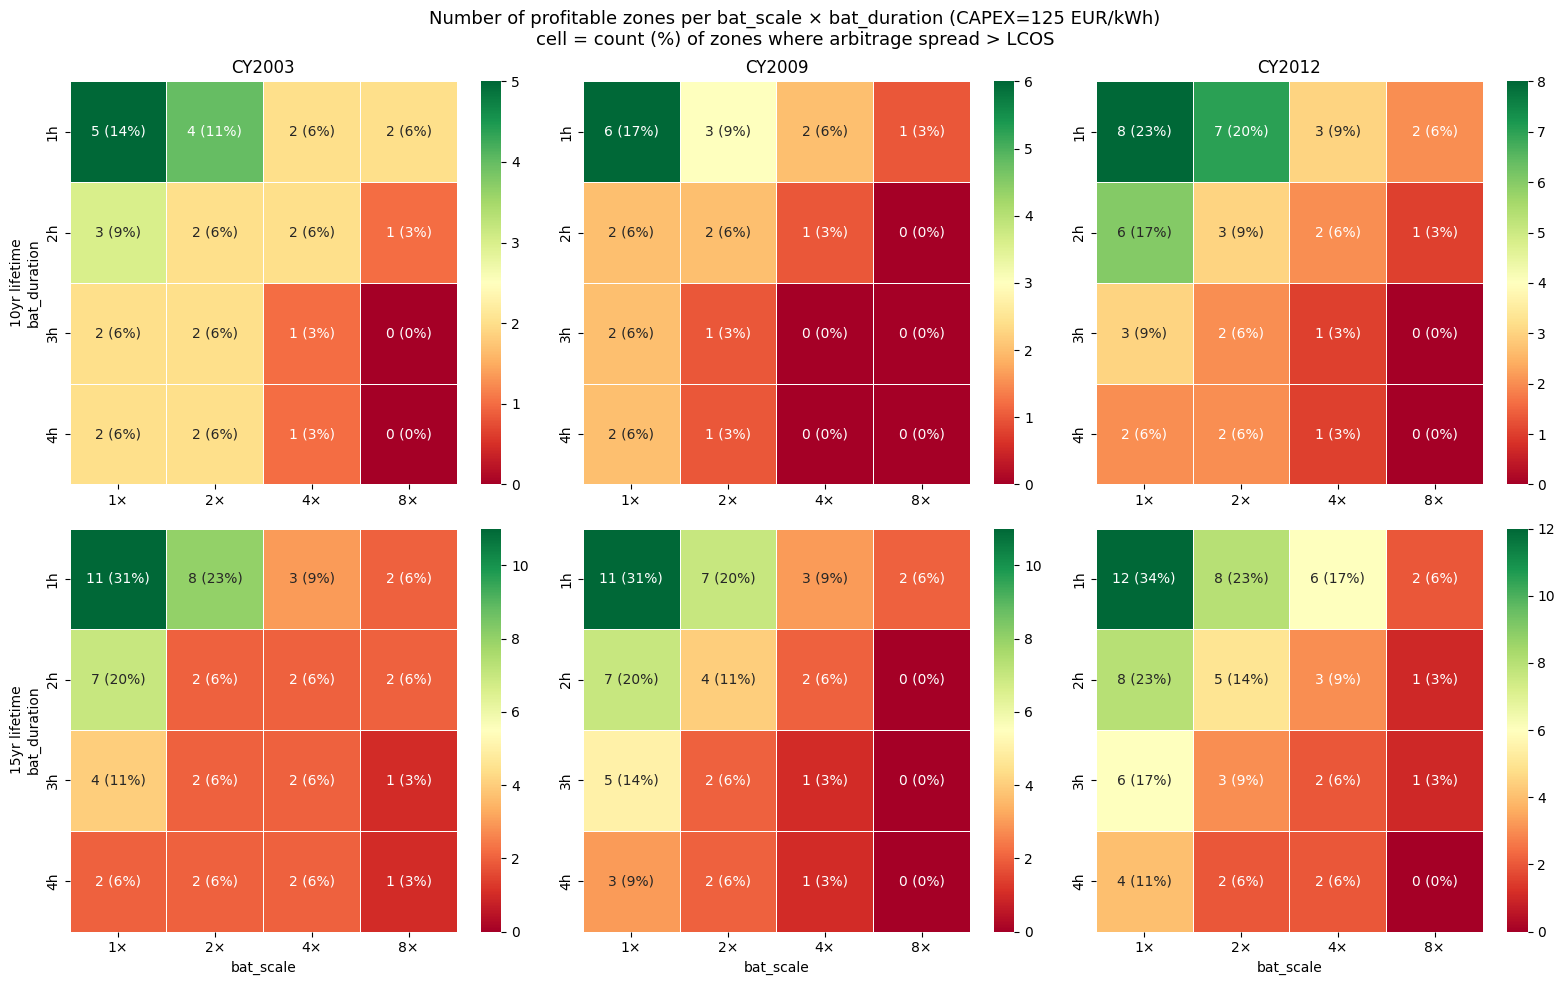

In [13]:
# Summary: how many zones are profitable per bat_scale × bat_duration?
# For each combo: compute LCOS profitability per zone, count profitable ones
# Rows: 2 (lifetime 10yr, 15yr) × 3 (CY), Cols: shown as heatmap bat_scale × bat_duration

CAPEX_S = 125
bat_all_s = static_su[static_su["carrier"] == "battery"]
bat_cols_s = [c for c in stor_cols if c in bat_all_s.index]
bat_bus_s = bat_all_s.loc[bat_cols_s, "bus"]

summary_records = []
for bs in [1, 2, 4, 8]:
    for dur in [1, 2, 3, 4]:
        for cy in [2003, 2009, 2012]:
            tag_row = results[
                (results["battery_scale"] == bs) &
                (results["battery_duration"] == dur) &
                (results["gas_price"] == 22.68) &
                (results["co2_price"] == 113.4) &
                (results["climate_year"] == cy)
            ]
            if len(tag_row) == 0:
                continue
            tag = tag_row["tag"].values[0]
            stor_tag = stor_p_all[stor_p_all["tag"] == tag]
            lmp_tag = lmp_all[lmp_all["tag"] == tag]

            for zone in sorted(bat_bus_s.unique()):
                zone_units = [c for c in bat_cols_s if bat_bus_s[c] == zone]
                if not zone_units or zone not in lmp_tag.columns:
                    continue
                lmp_zone = lmp_tag[zone].values
                total_dis_mwh, total_e_cap = 0, 0
                total_rev, total_cost, total_dis, total_ch = 0, 0, 0, 0
                for unit in zone_units:
                    power = stor_tag[unit].values
                    e_cap = bat_all_s.loc[unit, "p_nom"] * bs * bat_all_s.loc[unit, "max_hours"] * dur
                    if e_cap <= 0:
                        continue
                    discharge = np.where(power > 0, power, 0)
                    charge = np.where(power < 0, -power, 0)
                    total_dis_mwh += discharge.sum()
                    total_e_cap += e_cap
                    total_rev += (discharge * lmp_zone).sum()
                    total_dis += discharge.sum()
                    total_cost += (charge * lmp_zone).sum()
                    total_ch += charge.sum()
                if total_e_cap == 0 or total_dis == 0:
                    continue
                annual_cycles = total_dis_mwh / total_e_cap
                spread = (total_rev / total_dis) - (total_cost / total_ch if total_ch > 0 else 0)
                for lt in [10, 15]:
                    lcos = CAPEX_S / (annual_cycles * lt / 1000)
                    summary_records.append({
                        "bat_scale": bs, "bat_duration": dur,
                        "climate_year": cy, "lifetime": lt,
                        "zone": zone, "profitable": spread > lcos,
                    })
        print(f"  Done bat{bs}× dur{dur}×")

sum_df = pd.DataFrame(summary_records)

# Count profitable zones per combo
count_df = sum_df.groupby(["bat_scale", "bat_duration", "climate_year", "lifetime"])["profitable"].sum().reset_index()
total_zones = sum_df.groupby(["bat_scale", "bat_duration", "climate_year", "lifetime"])["zone"].nunique().reset_index()
count_df = count_df.merge(total_zones, on=["bat_scale", "bat_duration", "climate_year", "lifetime"])
count_df["pct"] = (count_df["profitable"] / count_df["zone"] * 100).round(0)

# Plot: 2 rows (lifetime) × 3 cols (CY), heatmap bat_scale × bat_duration inside
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
import seaborn as sns

for row_idx, lt in enumerate([10, 15]):
    for col_idx, cy in enumerate([2003, 2009, 2012]):
        ax = axes[row_idx, col_idx]
        sub = count_df[(count_df["lifetime"] == lt) & (count_df["climate_year"] == cy)]
        pivot = sub.pivot(index="bat_duration", columns="bat_scale", values="profitable")
        pivot = pivot.reindex(index=[1, 2, 3, 4], columns=[1, 2, 4, 8])
        
        # Also get percentage for annotation
        pivot_pct = sub.pivot(index="bat_duration", columns="bat_scale", values="pct")
        pivot_pct = pivot_pct.reindex(index=[1, 2, 3, 4], columns=[1, 2, 4, 8])
        
        # Custom annotation: "12 (34%)"
        annot = pivot.copy().astype(str)
        for r in annot.index:
            for c in annot.columns:
                n = pivot.loc[r, c]
                p = pivot_pct.loc[r, c]
                annot.loc[r, c] = f"{int(n)} ({int(p)}%)"

        sns.heatmap(pivot, annot=annot, fmt="", cmap="RdYlGn", ax=ax,
                    vmin=0, vmax=pivot.max().max(),
                    linewidths=0.5, linecolor="white",
                    xticklabels=[f"{s}×" for s in [1, 2, 4, 8]],
                    yticklabels=[f"{d}h" for d in [1, 2, 3, 4]])
        
        if row_idx == 0:
            ax.set_title(f"CY{cy}", fontsize=12)
        if col_idx == 0:
            ax.set_ylabel(f"{lt}yr lifetime\nbat_duration")
        else:
            ax.set_ylabel("")
        if row_idx == 1:
            ax.set_xlabel("bat_scale")
        else:
            ax.set_xlabel("")

fig.suptitle(f"Number of profitable zones per bat_scale × bat_duration (CAPEX={CAPEX_S} EUR/kWh)\n"
             f"cell = count (%) of zones where arbitrage spread > LCOS",
             fontsize=13)
plt.tight_layout()
plt.show()

  Done bat1× dur1×
  Done bat1× dur2×
  Done bat1× dur3×
  Done bat1× dur4×
  Done bat2× dur1×
  Done bat2× dur2×
  Done bat2× dur3×
  Done bat2× dur4×
  Done bat4× dur1×
  Done bat4× dur2×
  Done bat4× dur3×
  Done bat4× dur4×
  Done bat8× dur1×
  Done bat8× dur2×
  Done bat8× dur3×
  Done bat8× dur4×


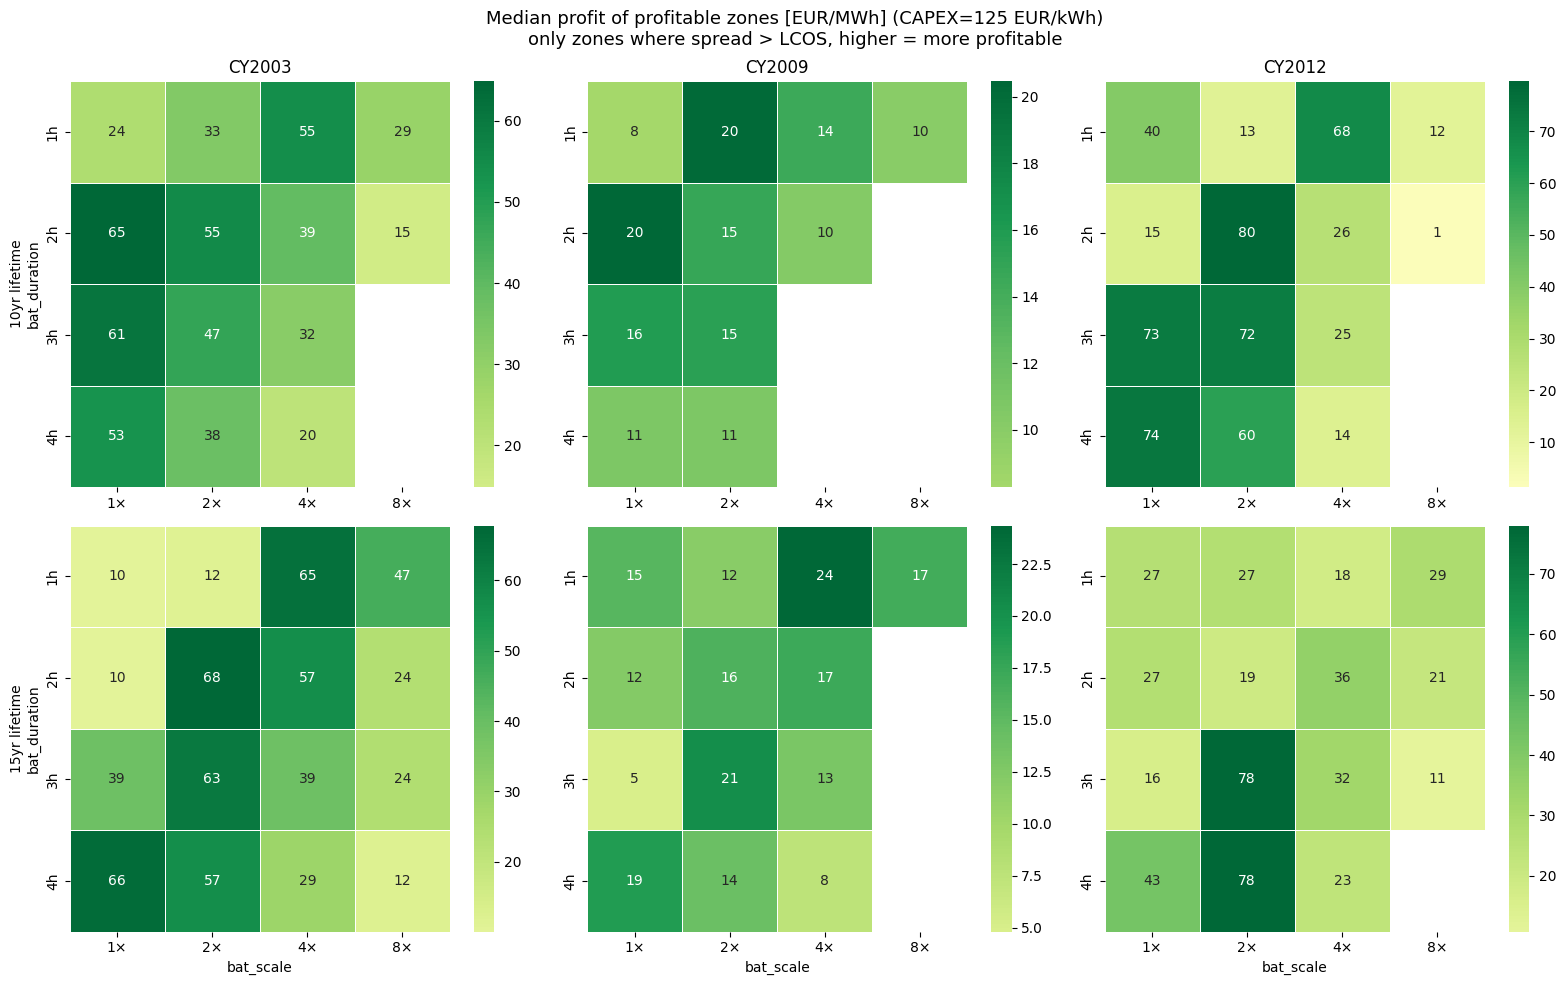

In [14]:
# Median profit per zone across bat_scale × bat_duration
# Reuse sum_df from previous cell — add profit column

# Recompute with actual profit values (not just boolean)
profit_records = []
for bs in [1, 2, 4, 8]:
    for dur in [1, 2, 3, 4]:
        for cy in [2003, 2009, 2012]:
            tag_row = results[
                (results["battery_scale"] == bs) &
                (results["battery_duration"] == dur) &
                (results["gas_price"] == 22.68) &
                (results["co2_price"] == 113.4) &
                (results["climate_year"] == cy)
            ]
            if len(tag_row) == 0:
                continue
            tag = tag_row["tag"].values[0]
            stor_tag = stor_p_all[stor_p_all["tag"] == tag]
            lmp_tag = lmp_all[lmp_all["tag"] == tag]

            for zone in sorted(bat_bus_s.unique()):
                zone_units = [c for c in bat_cols_s if bat_bus_s[c] == zone]
                if not zone_units or zone not in lmp_tag.columns:
                    continue
                lmp_zone = lmp_tag[zone].values
                total_dis_mwh, total_e_cap = 0, 0
                total_rev, total_cost, total_dis, total_ch = 0, 0, 0, 0
                for unit in zone_units:
                    power = stor_tag[unit].values
                    e_cap = bat_all_s.loc[unit, "p_nom"] * bs * bat_all_s.loc[unit, "max_hours"] * dur
                    if e_cap <= 0:
                        continue
                    discharge = np.where(power > 0, power, 0)
                    charge = np.where(power < 0, -power, 0)
                    total_dis_mwh += discharge.sum()
                    total_e_cap += e_cap
                    total_rev += (discharge * lmp_zone).sum()
                    total_dis += discharge.sum()
                    total_cost += (charge * lmp_zone).sum()
                    total_ch += charge.sum()
                if total_e_cap == 0 or total_dis == 0:
                    continue
                annual_cycles = total_dis_mwh / total_e_cap
                spread = (total_rev / total_dis) - (total_cost / total_ch if total_ch > 0 else 0)
                for lt in [10, 15]:
                    lcos = CAPEX_S / (annual_cycles * lt / 1000)
                    profit_records.append({
                        "bat_scale": bs, "bat_duration": dur,
                        "climate_year": cy, "lifetime": lt,
                        "zone": zone, "profit": spread - lcos,
                    })
        print(f"  Done bat{bs}× dur{dur}×")

prof_df = pd.DataFrame(profit_records)

# Median profit across zones
med_prof = prof_df[prof_df["profit"] > 0].groupby(["bat_scale", "bat_duration", "climate_year", "lifetime"])["profit"].median().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for row_idx, lt in enumerate([10, 15]):
    for col_idx, cy in enumerate([2003, 2009, 2012]):
        ax = axes[row_idx, col_idx]
        sub = med_prof[(med_prof["lifetime"] == lt) & (med_prof["climate_year"] == cy)]
        pivot = sub.pivot(index="bat_duration", columns="bat_scale", values="profit")
        pivot = pivot.reindex(index=[1, 2, 3, 4], columns=[1, 2, 4, 8])

        sns.heatmap(pivot, annot=True, fmt=".0f", cmap="RdYlGn", ax=ax,
                    center=0, linewidths=0.5, linecolor="white",
                    xticklabels=[f"{s}×" for s in [1, 2, 4, 8]],
                    yticklabels=[f"{d}h" for d in [1, 2, 3, 4]])

        if row_idx == 0:
            ax.set_title(f"CY{cy}", fontsize=12)
        if col_idx == 0:
            ax.set_ylabel(f"{lt}yr lifetime\nbat_duration")
        else:
            ax.set_ylabel("")
        if row_idx == 1:
            ax.set_xlabel("bat_scale")
        else:
            ax.set_xlabel("")

fig.suptitle(f"Median profit of profitable zones [EUR/MWh] (CAPEX={CAPEX_S} EUR/kWh)\n"
             f"only zones where spread > LCOS, higher = more profitable",
             fontsize=13)
plt.tight_layout()
plt.show()

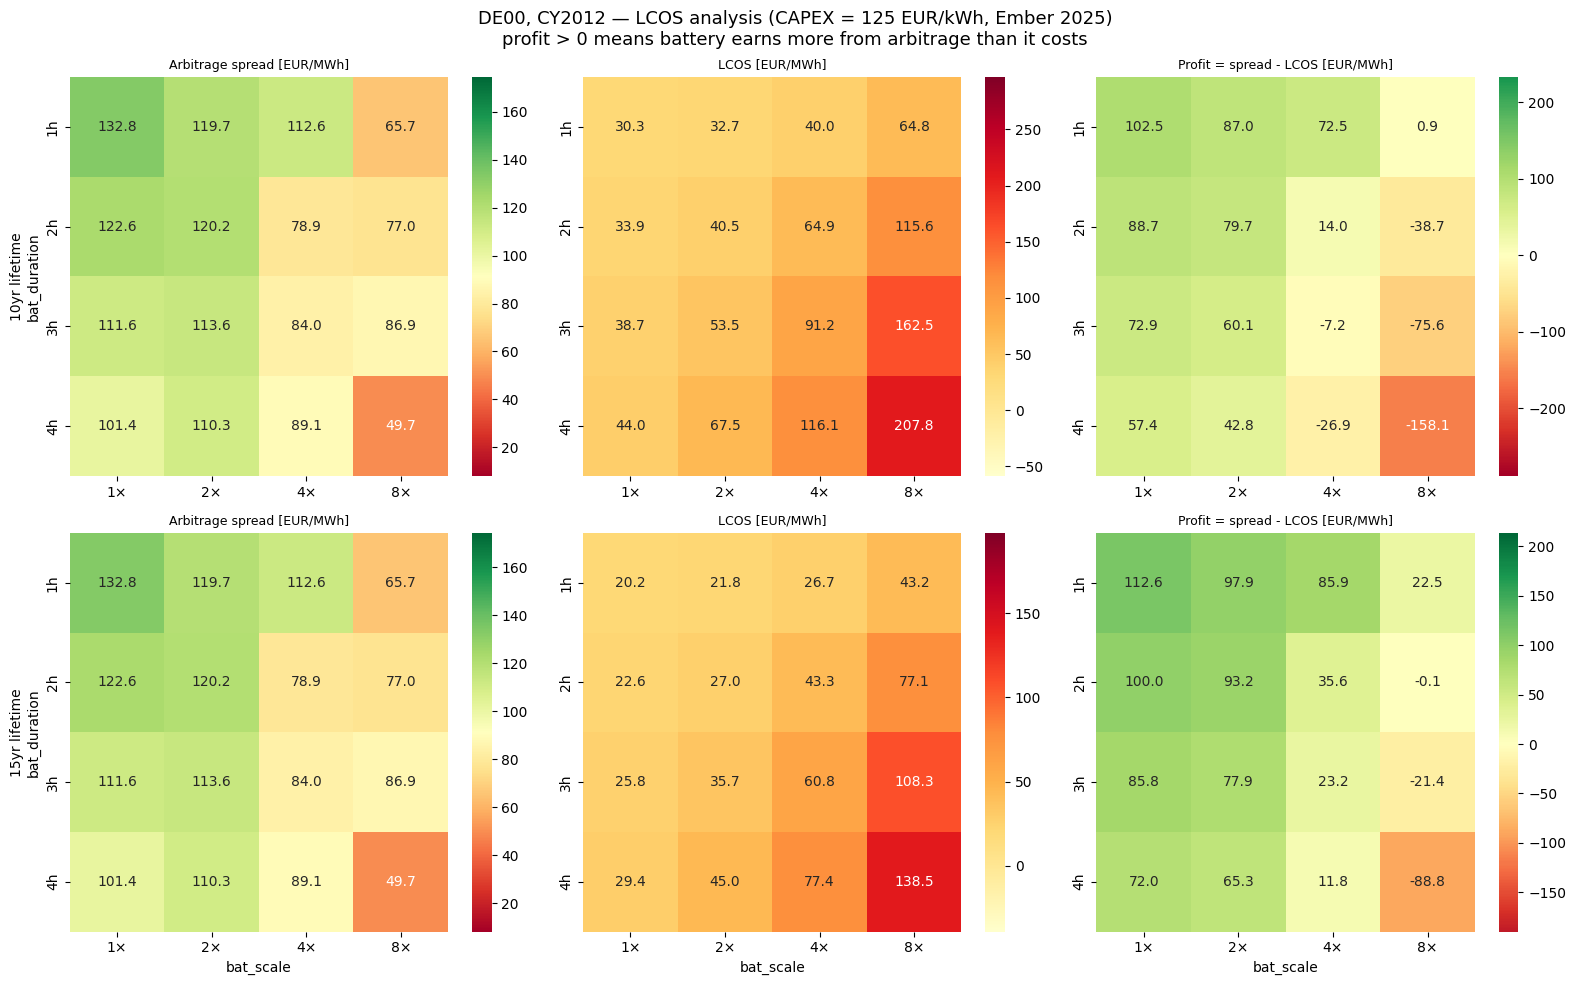


DE00 LCOS summary (CAPEX = 125 EUR/kWh)

  Lifetime = 10 years:
    bat1x dur1h: cycles=412/yr, spread=132.8, LCOS=30.3, profit=102.5 [+]
    bat1x dur2h: cycles=369/yr, spread=122.6, LCOS=33.9, profit=88.7 [+]
    bat1x dur3h: cycles=323/yr, spread=111.6, LCOS=38.7, profit=72.9 [+]
    bat1x dur4h: cycles=284/yr, spread=101.4, LCOS=44.0, profit=57.4 [+]
    bat2x dur1h: cycles=382/yr, spread=119.7, LCOS=32.7, profit=87.0 [+]
    bat2x dur2h: cycles=309/yr, spread=120.2, LCOS=40.5, profit=79.7 [+]
    bat2x dur3h: cycles=234/yr, spread=113.6, LCOS=53.5, profit=60.1 [+]
    bat2x dur4h: cycles=185/yr, spread=110.3, LCOS=67.5, profit=42.8 [+]
    bat4x dur1h: cycles=312/yr, spread=112.6, LCOS=40.0, profit=72.5 [+]
    bat4x dur2h: cycles=193/yr, spread=78.9, LCOS=64.9, profit=14.0 [+]
    bat4x dur3h: cycles=137/yr, spread=84.0, LCOS=91.2, profit=-7.2 [-]
    bat4x dur4h: cycles=108/yr, spread=89.1, LCOS=116.1, profit=-26.9 [-]
    bat8x dur1h: cycles=193/yr, spread=65.7, LCOS=64.8, pro

In [15]:
# LCOS vs arbitrage spread — DE00 only
CAPEX_KWHR_DE = 125  # EUR/kWh (Ember 2025)
LIFETIMES_DE = [10, 15]

FIX_GAS_DE, FIX_CO2_DE, FIX_CY_DE = 22.68, 113.4, 2012
bat_units_de = static_su[static_su["carrier"] == "battery"]
bat_cols_de = [c for c in stor_cols if c in bat_units_de.index]
bat_bus_de = bat_units_de.loc[bat_cols_de, "bus"]
de_bat_cols = [c for c in bat_cols_de if bat_bus_de[c] == "DE00"]
bat_info_de = bat_units_de.loc[de_bat_cols, ["p_nom", "max_hours"]].copy()

lcos_de_records = []
for bs in [1, 2, 4, 8]:
    for dur in [1, 2, 3, 4]:
        tag_row = results[
            (results["battery_scale"] == bs) &
            (results["battery_duration"] == dur) &
            (results["gas_price"] == FIX_GAS_DE) &
            (results["co2_price"] == FIX_CO2_DE) &
            (results["climate_year"] == FIX_CY_DE)
        ]
        if len(tag_row) == 0:
            continue
        tag = tag_row["tag"].values[0]

        stor_tag = stor_p_all[stor_p_all["tag"] == tag]
        lmp_tag = lmp_all[lmp_all["tag"] == tag]
        lmp_de = lmp_tag["DE00"].values

        total_discharge_mwh = 0
        total_e_cap_mwh = 0
        total_revenue = 0
        total_cost = 0
        total_dis = 0
        total_ch = 0

        for unit in de_bat_cols:
            power = stor_tag[unit].values
            e_cap = bat_info_de.loc[unit, "p_nom"] * bs * bat_info_de.loc[unit, "max_hours"] * dur
            if e_cap <= 0:
                continue

            discharge = np.where(power > 0, power, 0)
            charge = np.where(power < 0, -power, 0)

            total_discharge_mwh += discharge.sum()
            total_e_cap_mwh += e_cap
            total_revenue += (discharge * lmp_de).sum()
            total_dis += discharge.sum()
            total_cost += (charge * lmp_de).sum()
            total_ch += charge.sum()

        annual_cycles = total_discharge_mwh / total_e_cap_mwh if total_e_cap_mwh > 0 else 0
        avg_sell = total_revenue / total_dis if total_dis > 0 else 0
        avg_buy = total_cost / total_ch if total_ch > 0 else 0
        spread = avg_sell - avg_buy

        for lifetime in LIFETIMES_DE:
            total_cycles_lifetime = annual_cycles * lifetime
            lcos = CAPEX_KWHR_DE / (total_cycles_lifetime / 1000) if total_cycles_lifetime > 0 else 999
            profit = spread - lcos
            lcos_de_records.append({
                "bat_scale": bs, "bat_duration": dur, "lifetime": lifetime,
                "annual_cycles": annual_cycles, "spread": spread,
                "lcos": lcos, "profit": profit,
            })

lcos_de_df = pd.DataFrame(lcos_de_records)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
import seaborn as sns

for row_idx, lt in enumerate(LIFETIMES_DE):
    sub = lcos_de_df[lcos_de_df["lifetime"] == lt]
    for col_idx, (col, title, cmap_name) in enumerate([
        ("spread", "Arbitrage spread [EUR/MWh]", "RdYlGn"),
        ("lcos", "LCOS [EUR/MWh]", "YlOrRd"),
        ("profit", "Profit = spread - LCOS [EUR/MWh]", "RdYlGn"),
    ]):
        ax = axes[row_idx, col_idx]
        pivot = sub.pivot(index="bat_duration", columns="bat_scale", values=col)
        pivot = pivot.reindex(index=[1, 2, 3, 4], columns=[1, 2, 4, 8])
        data_range = pivot.max().max() - pivot.min().min()
        pad = max(data_range * 0.5, 3)
        center = 0 if col == "profit" else None
        sns.heatmap(pivot, annot=True, fmt=".1f", cmap=cmap_name, ax=ax,
                    linewidths=0, vmin=pivot.min().min()-pad, vmax=pivot.max().max()+pad,
                    center=center,
                    xticklabels=[f"{s}×" for s in [1, 2, 4, 8]],
                    yticklabels=[f"{d}h" for d in [1, 2, 3, 4]])
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("bat_scale" if row_idx == 1 else "")
        if col_idx == 0:
            ax.set_ylabel(f"{lt}yr lifetime\nbat_duration")
        else:
            ax.set_ylabel("")

fig.suptitle(f"DE00, CY2012 — LCOS analysis (CAPEX = {CAPEX_KWHR_DE} EUR/kWh, Ember 2025)\n"
             f"profit > 0 means battery earns more from arbitrage than it costs",
             fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nDE00 LCOS summary (CAPEX = {CAPEX_KWHR_DE} EUR/kWh)")
for lt in LIFETIMES_DE:
    sub = lcos_de_df[lcos_de_df["lifetime"] == lt]
    print(f"\n  Lifetime = {lt} years:")
    for _, r in sub.iterrows():
        marker = "+" if r["profit"] > 0 else "-"
        print(f"    bat{r['bat_scale']:.0f}x dur{r['bat_duration']:.0f}h: "
              f"cycles={r['annual_cycles']:.0f}/yr, spread={r['spread']:.1f}, "
              f"LCOS={r['lcos']:.1f}, profit={r['profit']:.1f} [{marker}]")

In [16]:
# # EU-wide median spread per scenario
# eu_spread_reg = spread_df.groupby(["tag", "battery_scale", "battery_duration",
#                                     "gas_price", "co2_price", "climate_year"])["spread"].median().reset_index()

# X = eu_spread_reg[["battery_scale", "battery_duration", "gas_price", "co2_price", "climate_year"]].astype(float)
# X = sm.add_constant(X)
# y = eu_spread_reg["spread"].astype(float)
# model_spread = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 10})

# print("Spread regression (HAC):")
# print(f"R² = {model_spread.rsquared:.3f}")
# print()
# for var in ["battery_scale", "battery_duration", "gas_price", "co2_price", "climate_year"]:
#     sig = "***" if model_spread.pvalues[var] < 0.001 else "**" if model_spread.pvalues[var] < 0.01 else "*" if model_spread.pvalues[var] < 0.05 else "ns"
#     print(f"  {var:20s}: {model_spread.params[var]:+.4f}  (t={model_spread.tvalues[var]:.2f}) {sig}")

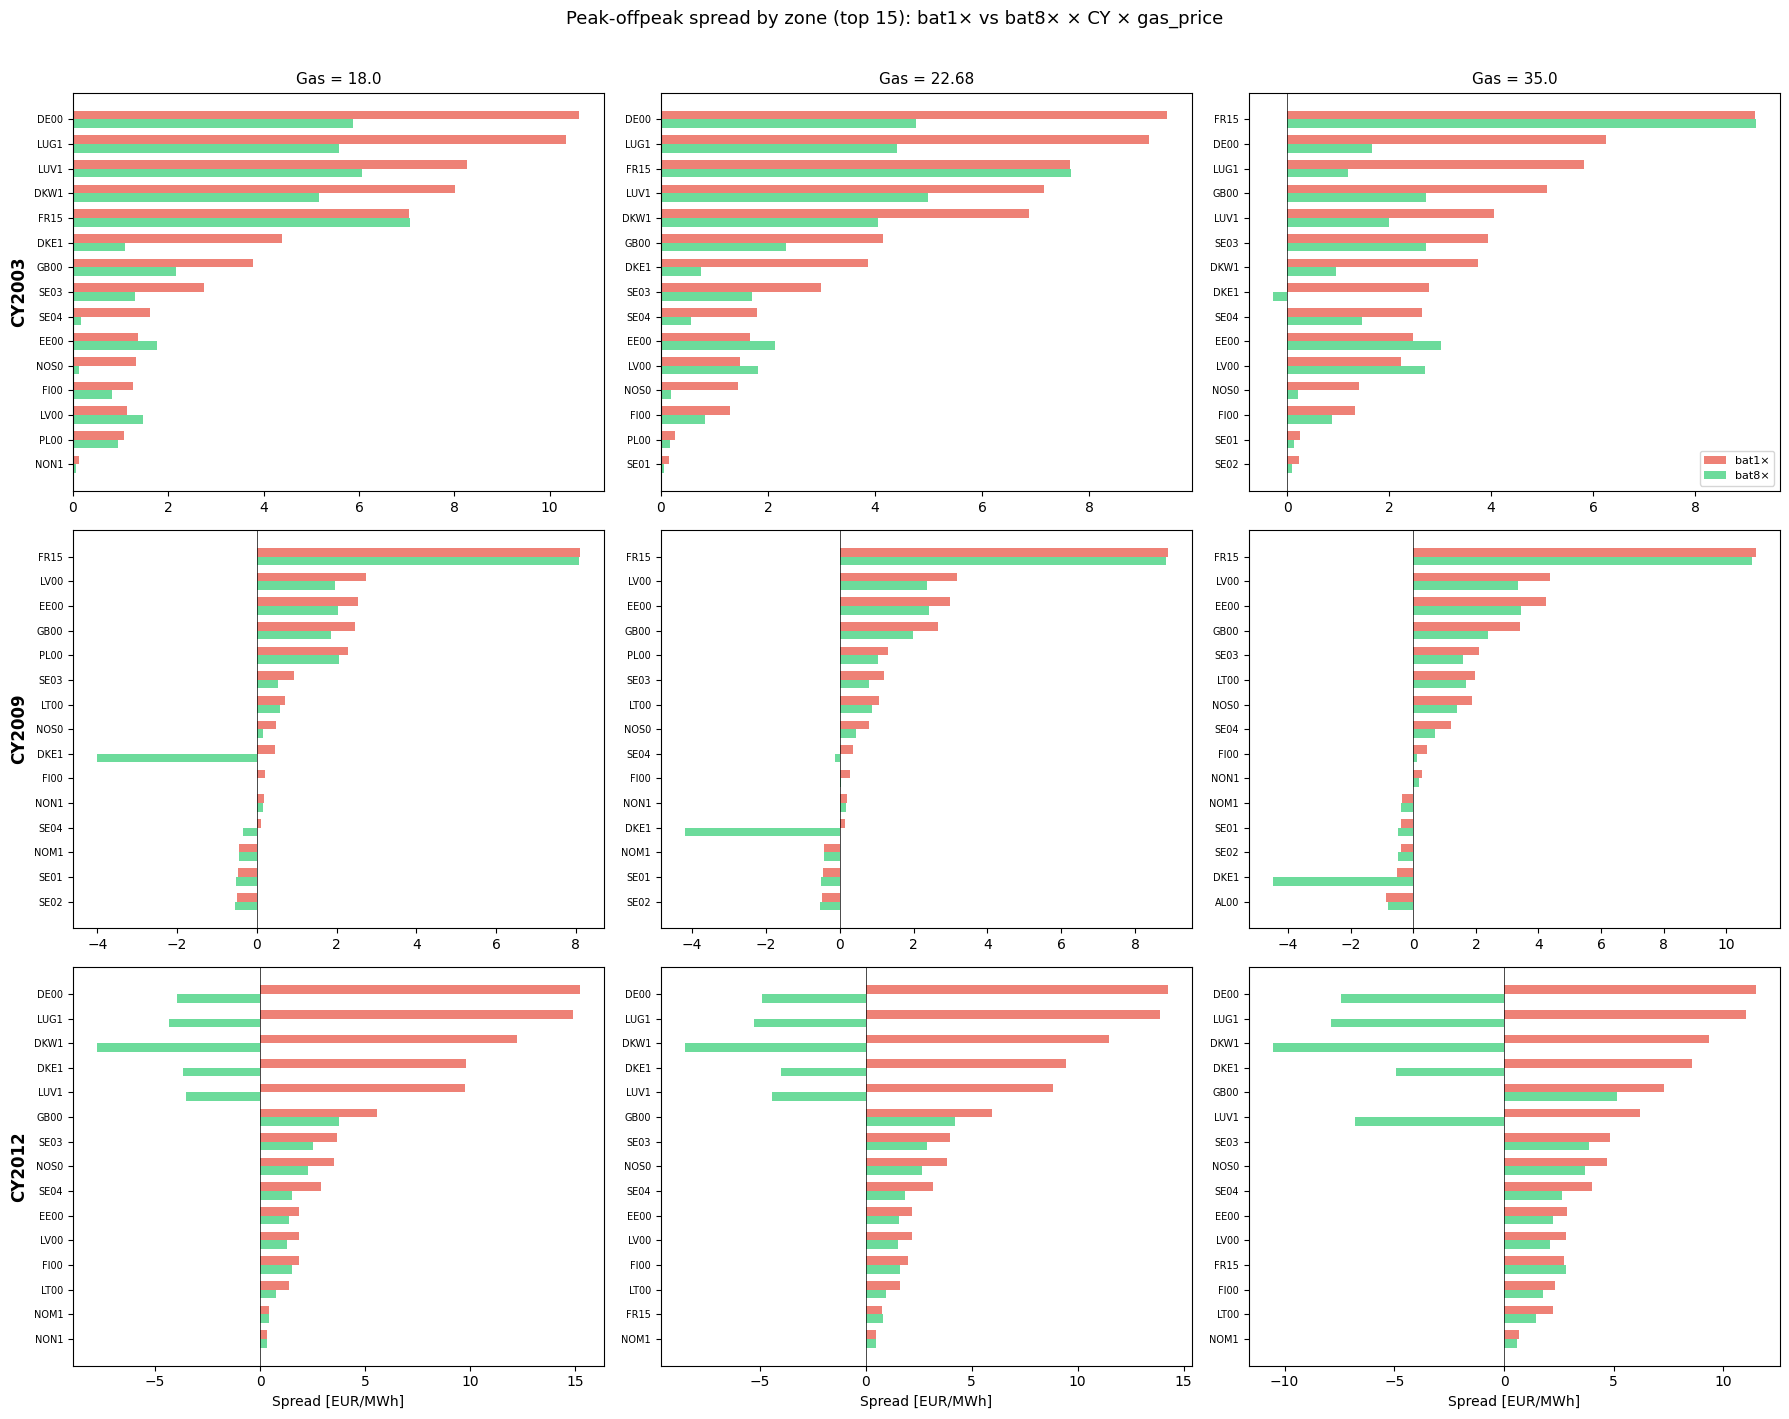

In [17]:
# Spread per zone — 3×3 grid (CY rows × gas cols)
# Each panel: top 15 zones by |spread| at bat1×, comparing bat1× vs bat8×
CYS = [2003, 2009, 2012]
GAS = [18.0, 22.68, 35.0]
TOP_N = 15

fig, axes = plt.subplots(3, 3, figsize=(18, 14), sharex=False, sharey=False)

for row, cy in enumerate(CYS):
    for col, gp in enumerate(GAS):
        ax = axes[row, col]
        sub = spread_df[(spread_df["climate_year"] == cy) & (spread_df["gas_price"] == gp)]

        s1 = sub[sub["battery_scale"] == 1].groupby("zone")["spread"].median().sort_values(ascending=False)
        s8 = sub[sub["battery_scale"] == 8].groupby("zone")["spread"].median()

        top_zones = s1.head(TOP_N).index
        s1_top = s1.loc[top_zones]
        s8_top = s8.reindex(top_zones)

        x = np.arange(TOP_N)
        w = 0.35
        ax.barh(x - w/2, s1_top.values, w, label="bat1×", color="#e74c3c", alpha=0.7)
        ax.barh(x + w/2, s8_top.values, w, label="bat8×", color="#2ecc71", alpha=0.7)
        ax.set_yticks(x)
        ax.set_yticklabels(top_zones, fontsize=7)
        ax.invert_yaxis()
        ax.axvline(0, color="k", lw=0.5)

        if row == 0:
            ax.set_title(f"Gas = {gp}", fontsize=11)
        if col == 0:
            ax.set_ylabel(f"CY{cy}", fontsize=12, fontweight="bold")
        if row == 2:
            ax.set_xlabel("Spread [EUR/MWh]")
        if row == 0 and col == 2:
            ax.legend(fontsize=8, loc="lower right")

plt.suptitle("Peak-offpeak spread by zone (top 15): bat1× vs bat8× × CY × gas_price", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## B. Technology Capture Rates

**Capture rate** = generation-weighted average price / system average price.

Capture rate measures at what price a technology sells electricity compared to the system average.
For example, a capture rate of 1.6 for gas means gas plants sell at 160% of the system average price — they produce mainly during expensive hours (peaks, nights without solar).

- **CR > 1:** technology generates when prices are above average (e.g., gas — ramps up during peaks)
- **CR = 1:** earns exactly the system average
- **CR < 1:** technology generates when prices are below average (e.g., solar — produces midday when solar suppresses prices)

Expected effect: batteries should increase solar/wind CR (absorb surplus → lift low-price hours) and decrease gas CR (replace peaks → lower peak prices).

In [18]:
# Capture rate computation (data already loaded in Cell 1)
cr_records = []

for i, tag in enumerate(results["tag"].values):
    lmp_tag = lmp_all[lmp_all["tag"] == tag][bus_cols].values  # 8760 x 55
    gen_tag = gen_p_all[gen_p_all["tag"] == tag][gen_cols].values  # 8760 x 557

    # System average price (generation-weighted)
    total_gen_per_zone = np.zeros(len(bus_cols))
    for gi, gname in enumerate(gen_cols):
        if gname in static_gen.index:
            bus = static_gen.loc[gname, "bus"]
            if bus in bus_cols:
                bi = bus_cols.index(bus)
                total_gen_per_zone[bi] += gen_tag[:, gi].sum()

    sys_price = np.sum(lmp_tag.mean(axis=0) * total_gen_per_zone) / total_gen_per_zone.sum() if total_gen_per_zone.sum() > 0 else np.nan

    for carrier in KEY_CARRIERS:
        units = static_gen[static_gen["carrier"] == carrier].index
        units_in = [u for u in units if u in gen_cols]
        if not units_in:
            continue

        total_revenue = 0
        total_generation = 0
        for u in units_in:
            gi = gen_cols.index(u)
            bus = static_gen.loc[u, "bus"]
            if bus not in bus_cols:
                continue
            bi = bus_cols.index(bus)
            gen_u = gen_tag[:, gi]
            lmp_u = lmp_tag[:, bi]
            total_revenue += (gen_u * lmp_u).sum()
            total_generation += gen_u.sum()

        if total_generation > 0 and sys_price > 0:
            capture_price = total_revenue / total_generation
            cr = capture_price / sys_price
            cr_records.append({"tag": tag, "carrier": carrier, "capture_rate": cr,
                              "capture_price": capture_price, "sys_price": sys_price})

    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/432...")

cr_df = pd.DataFrame(cr_records).merge(
    results[["tag", "battery_scale", "battery_duration", "gas_price", "co2_price", "climate_year"]],
    on="tag"
)
print(f"Capture rate data: {len(cr_df)} rows")
print(f"\nMean capture rate by carrier:")
print(cr_df.groupby("carrier")["capture_rate"].mean().round(3).sort_values(ascending=False))

  Processed 100/432...
  Processed 200/432...
  Processed 300/432...
  Processed 400/432...
Capture rate data: 2592 rows

Mean capture rate by carrier:
carrier
gas                 1.619
nuclear             1.082
hydro-ror           1.078
onwind              0.810
offwind             0.746
solar-pv-utility    0.694
Name: capture_rate, dtype: float64


In [19]:
# Export for thesis
fig.savefig("../tukedip_pdflatex_utf-8/figures/fig_capture_rates.jpg", dpi=200, bbox_inches="tight")
print("Saved fig_capture_rates.jpg")

Saved fig_capture_rates.jpg


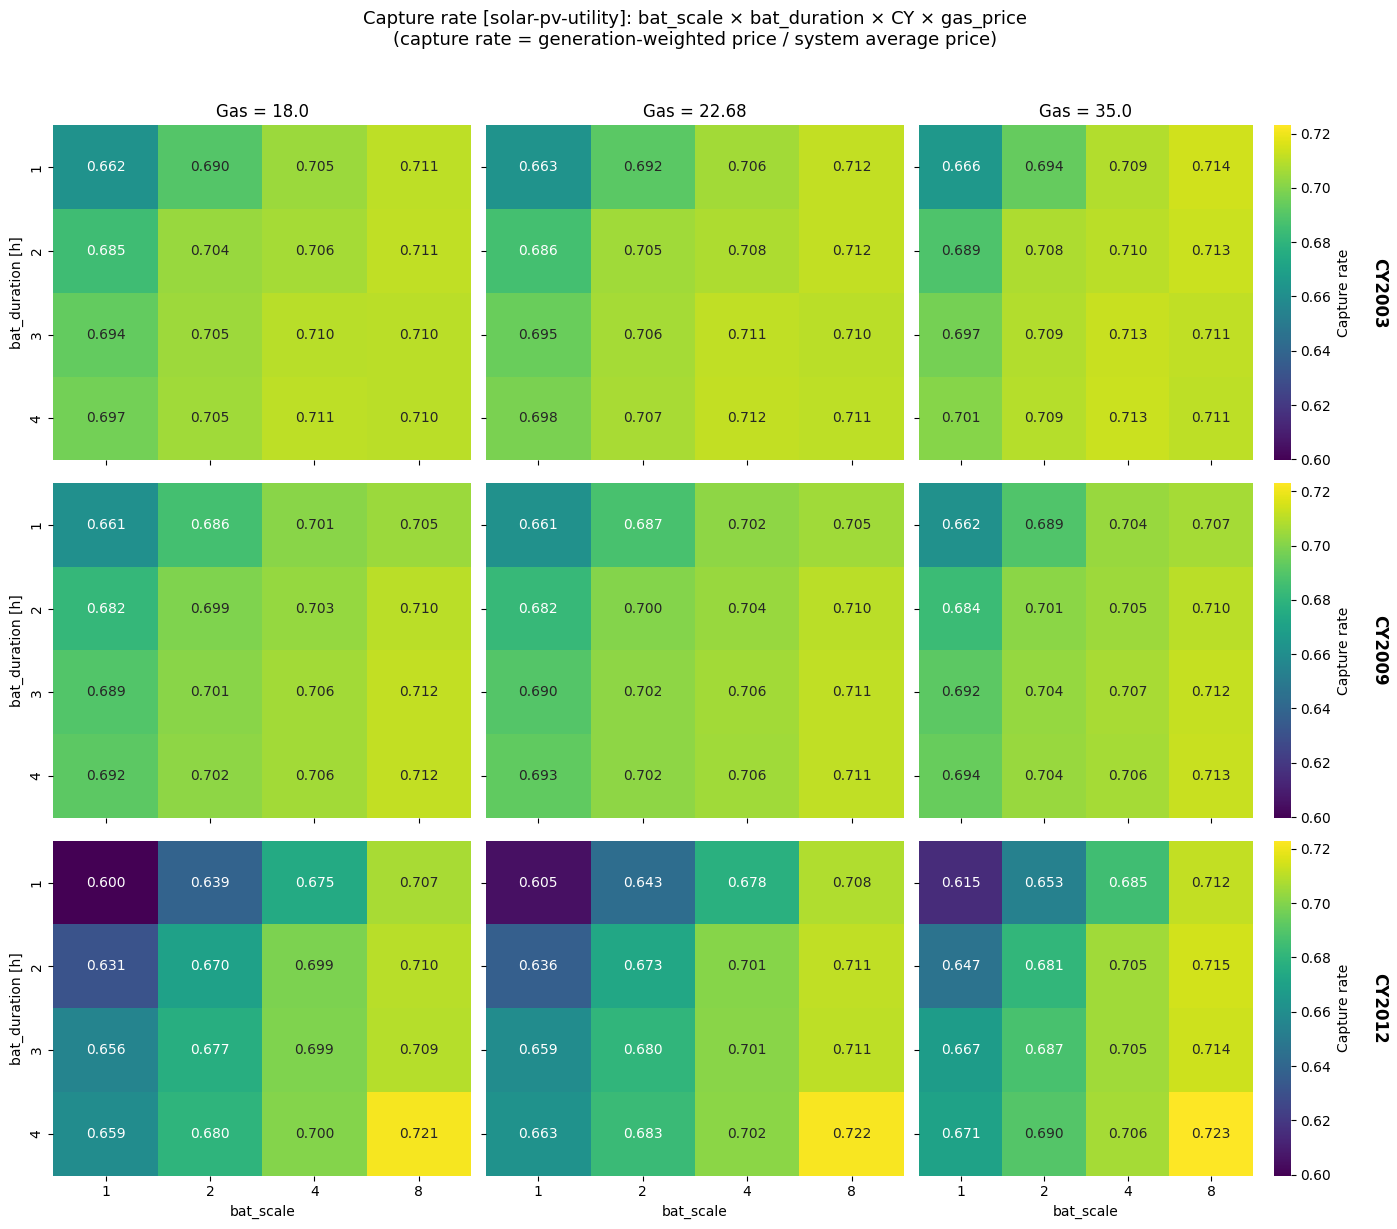

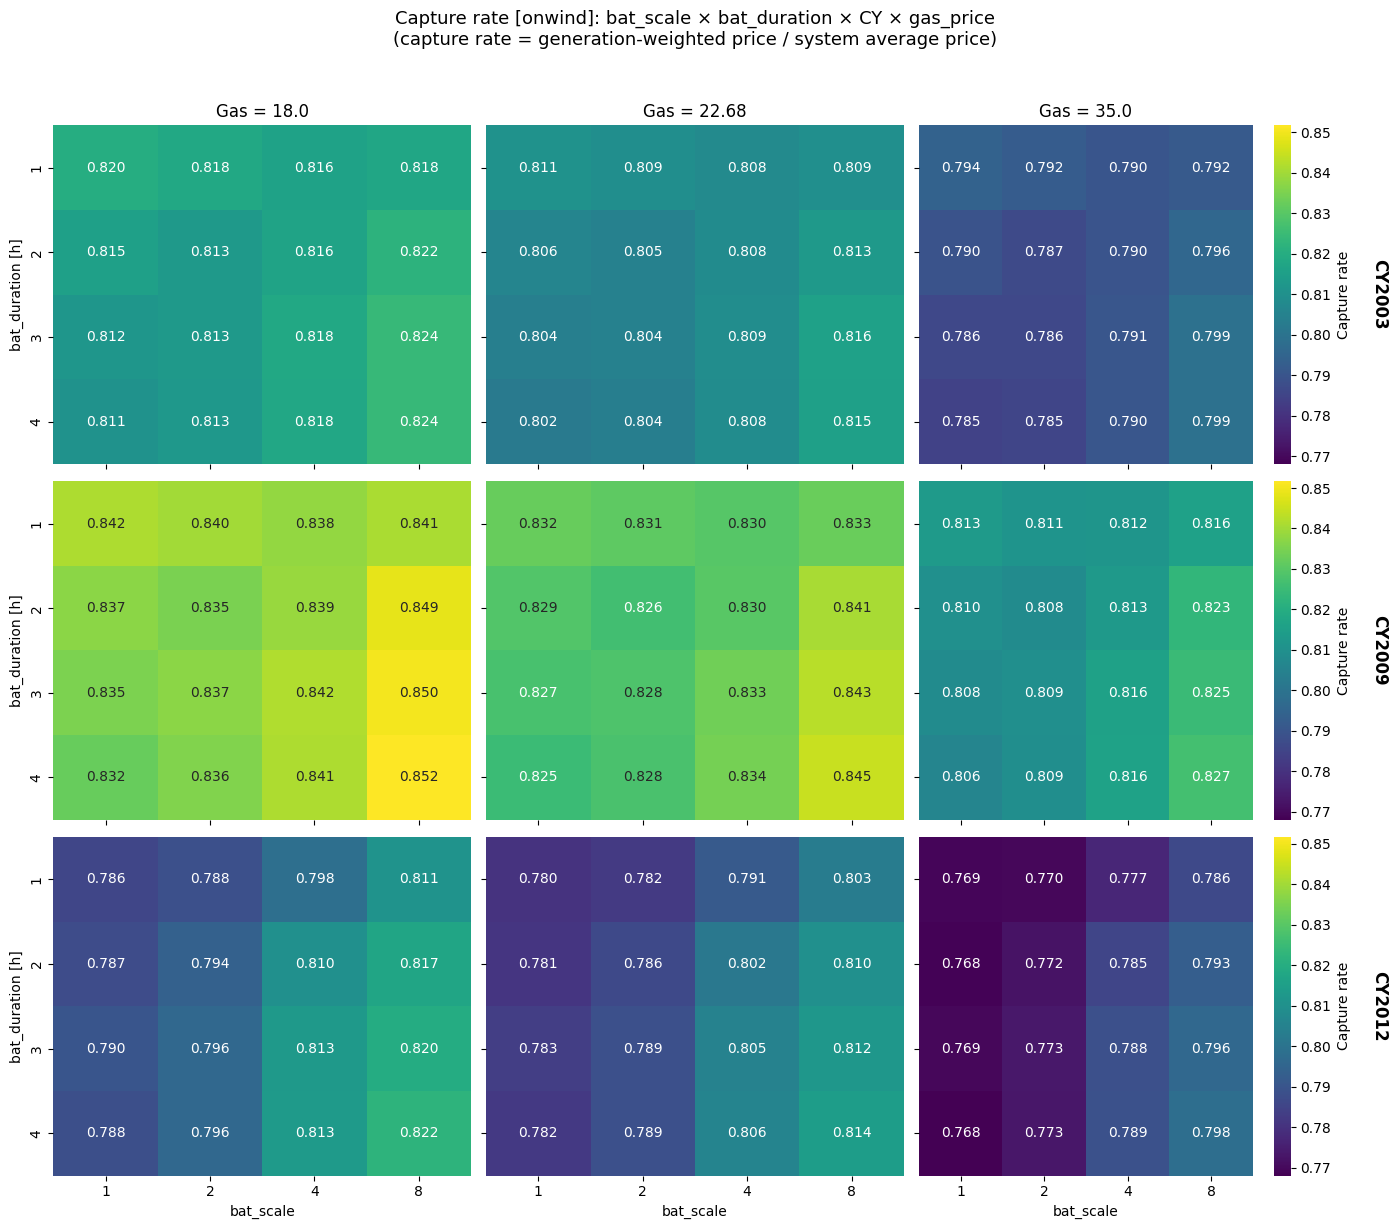

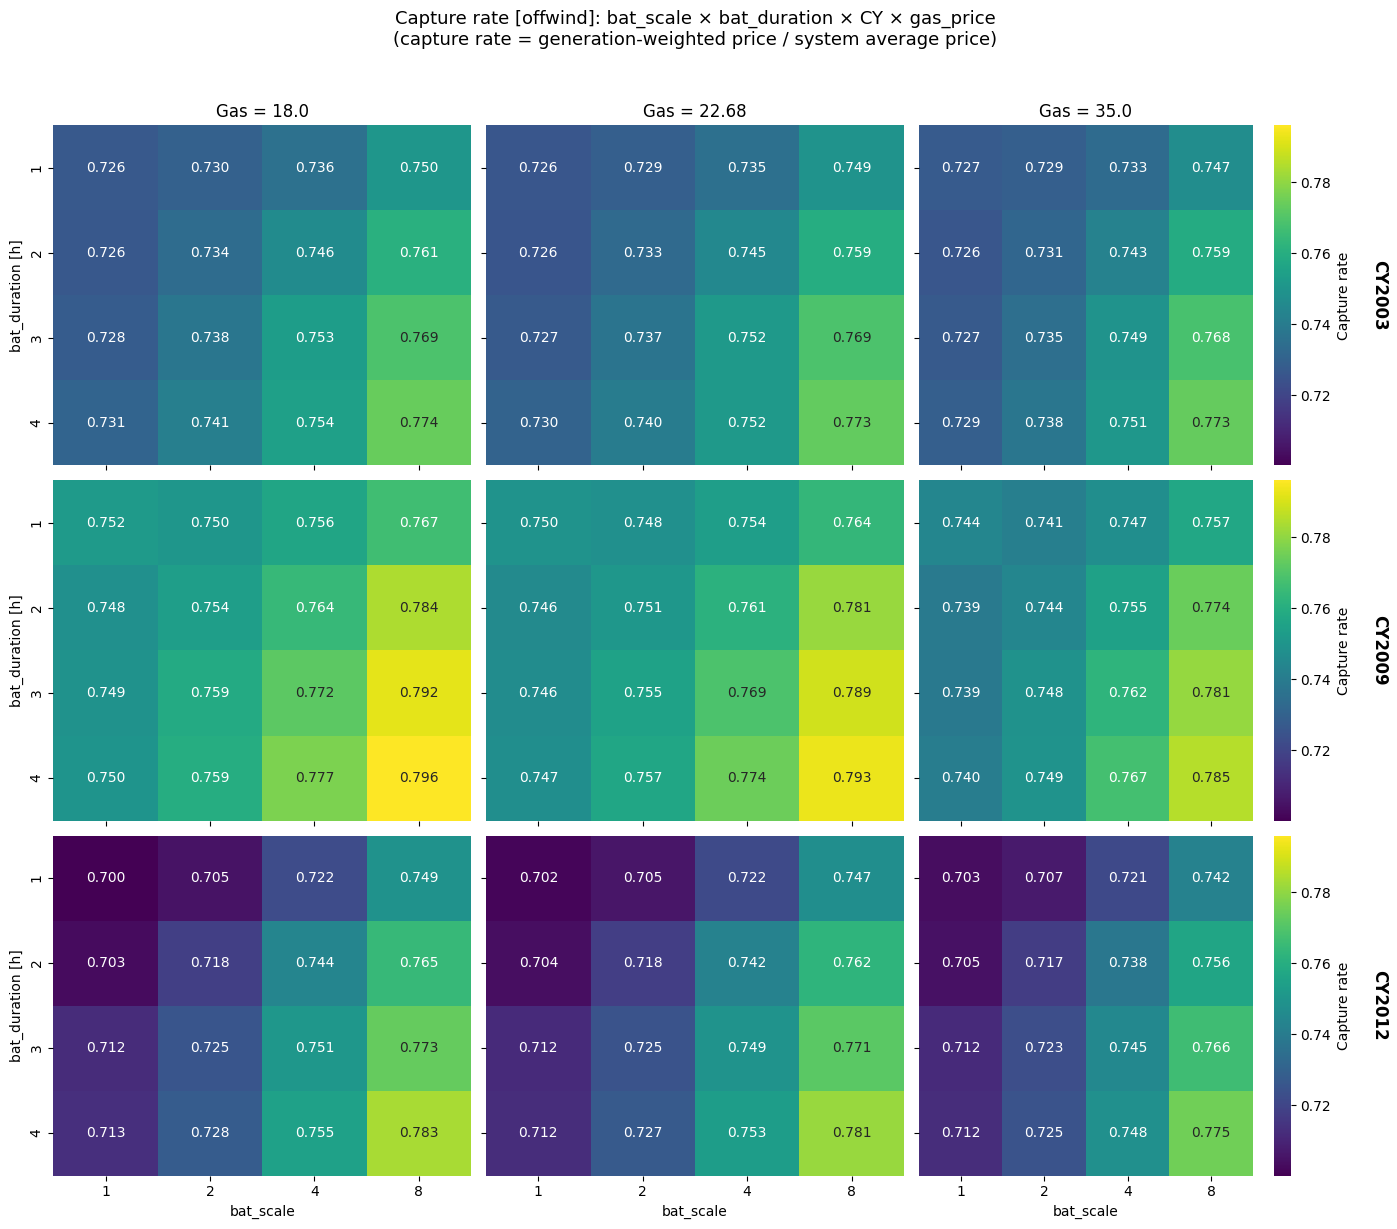

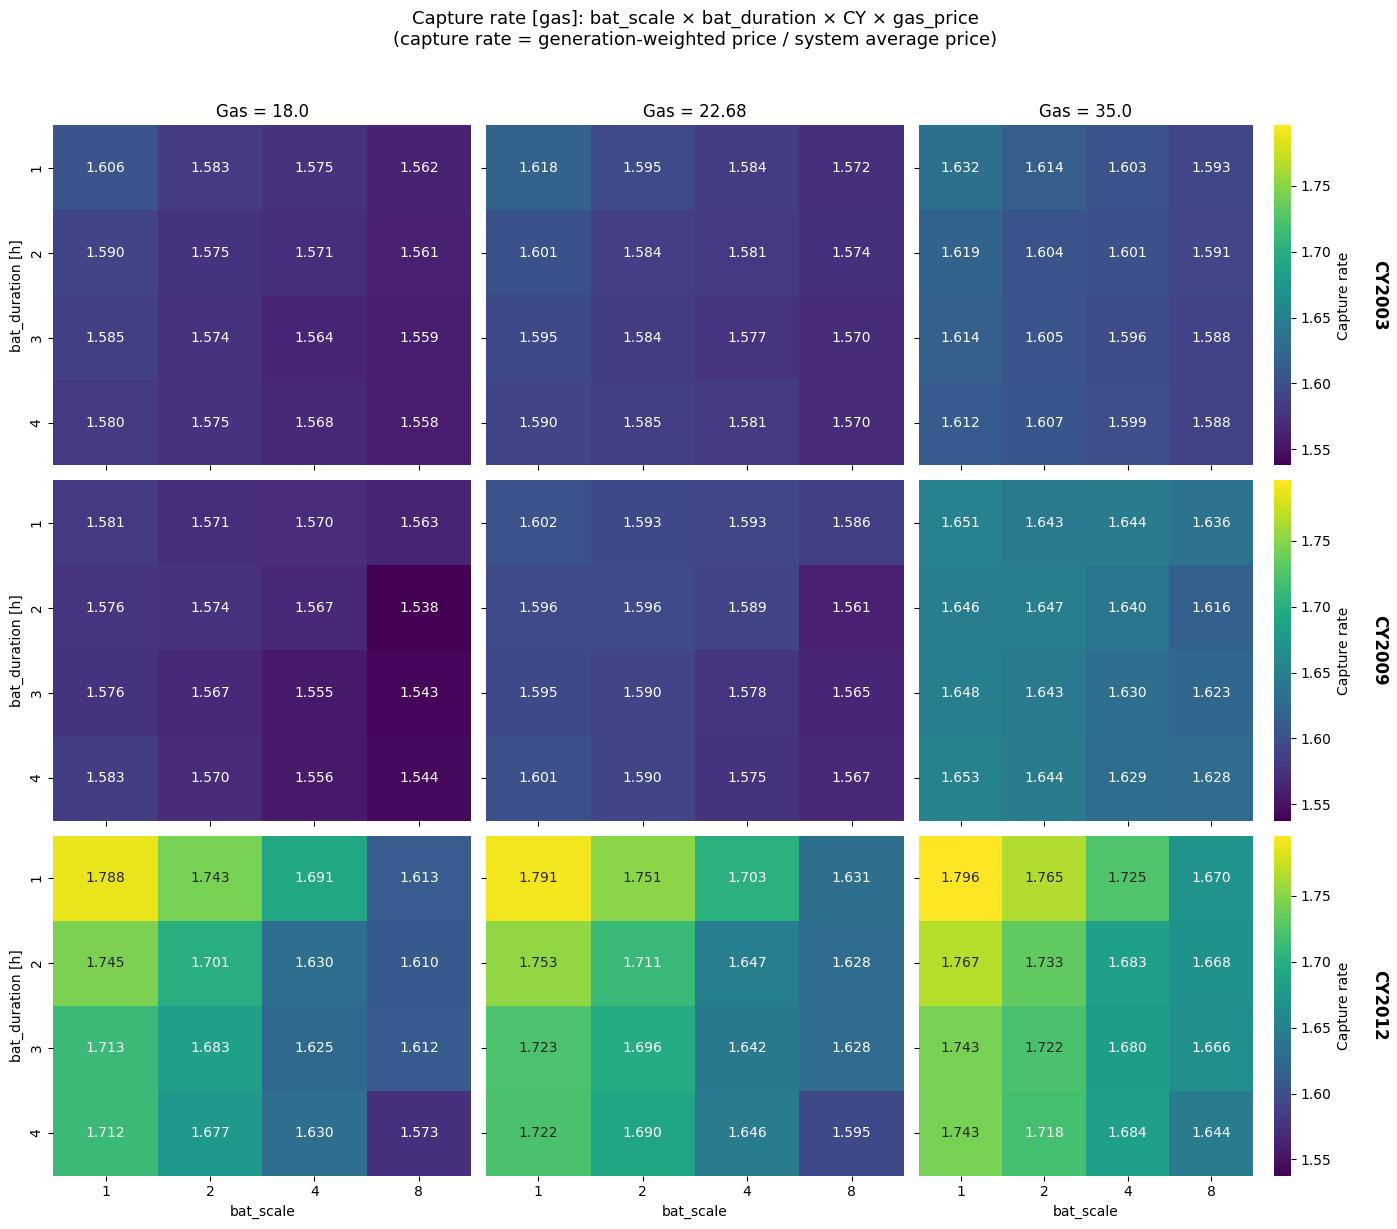

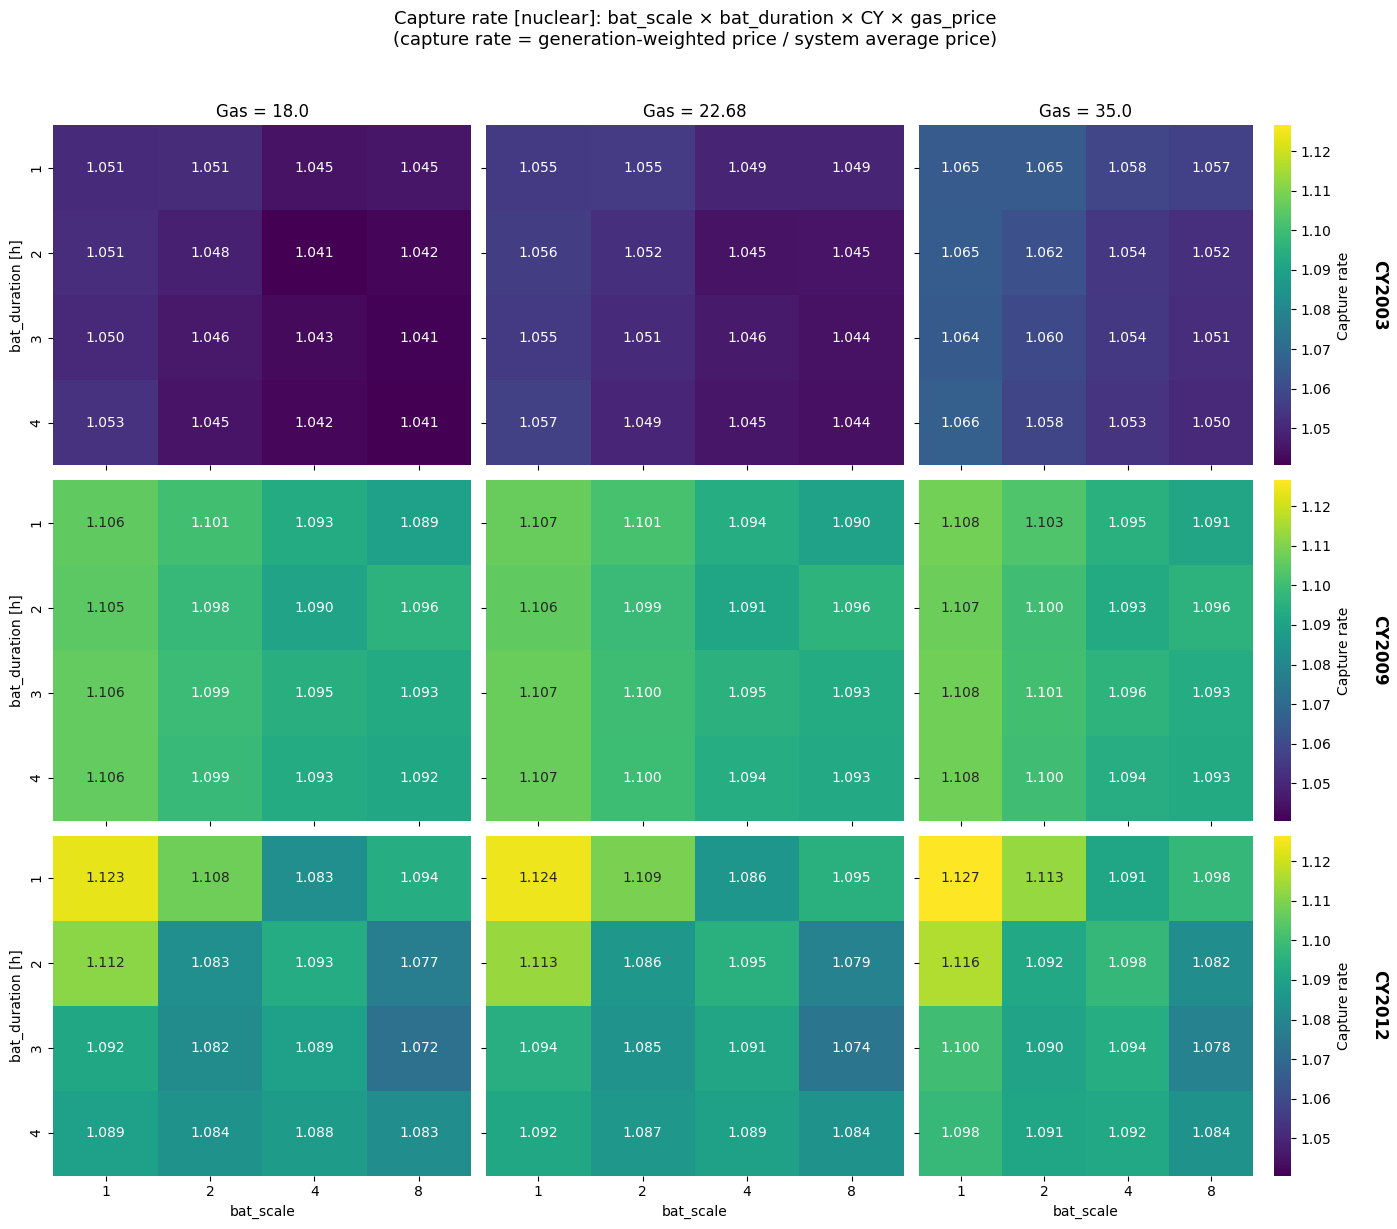

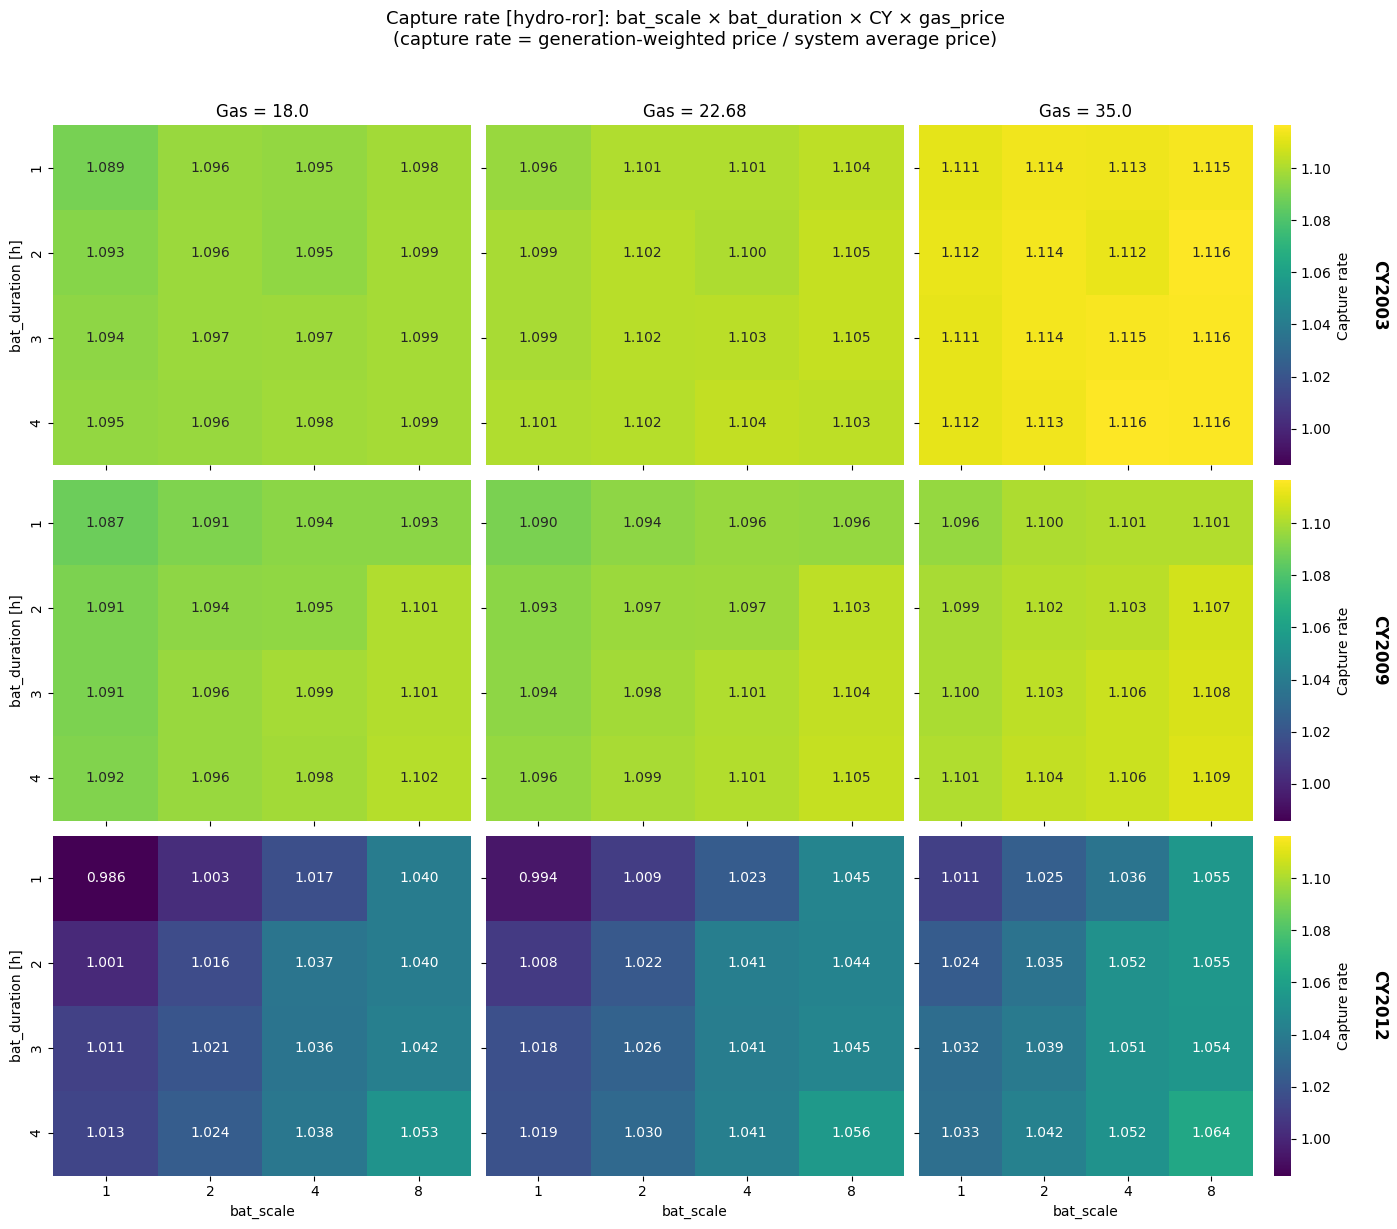

In [20]:
# Capture rate — one 3×3 heatmap per carrier (CY rows × gas cols, bat_scale × bat_duration inside)
CYS = [2003, 2009, 2012]
GAS = [18.0, 22.68, 35.0]

for carrier in KEY_CARRIERS:
    cr_carrier = cr_df[cr_df["carrier"] == carrier]
    if cr_carrier.empty:
        continue

    fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=True, sharey=True)

    # Per-carrier color range (no forced center — let data speak)
    all_medians = cr_carrier.groupby(["climate_year", "gas_price", "battery_duration", "battery_scale"])["capture_rate"].median()
    vmin, vmax = all_medians.min(), all_medians.max()

    for row, cy in enumerate(CYS):
        for col, gp in enumerate(GAS):
            ax = axes[row, col]
            sub = cr_carrier[(cr_carrier["climate_year"] == cy) & (cr_carrier["gas_price"] == gp)]
            pivot = sub.groupby(["battery_duration", "battery_scale"])["capture_rate"].median().reset_index()
            hm = pivot.pivot(index="battery_duration", columns="battery_scale", values="capture_rate")

            sns.heatmap(hm, annot=True, fmt=".3f", cmap="viridis", ax=ax,
                        cbar=col == 2, vmin=vmin, vmax=vmax,
                        cbar_kws={"label": "Capture rate"} if col == 2 else {})
            ax.set_xlabel("bat_scale" if row == 2 else "")
            ax.set_ylabel("bat_duration [h]" if col == 0 else "")

            if row == 0:
                ax.set_title(f"Gas = {gp}")
            if col == 2:
                ax.yaxis.set_label_position("right")
                ax.text(1.35, 0.5, f"CY{cy}", transform=ax.transAxes,
                        rotation=-90, va="center", fontsize=12, fontweight="bold")

    plt.suptitle(f"Capture rate [{carrier}]: bat_scale × bat_duration × CY × gas_price\n(capture rate = generation-weighted price / system average price)", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

In [21]:
# Battery capture ratio (data already loaded in Cell 1)
bat_units = static_su[static_su["carrier"] == "battery"].index

bat_records = []
for i, tag in enumerate(results["tag"].values):
    stor_tag = stor_p_all[stor_p_all["tag"] == tag][stor_cols].values
    lmp_tag = lmp_all[lmp_all["tag"] == tag][bus_cols].values

    total_discharge_rev = 0
    total_discharge_mwh = 0
    total_charge_cost = 0
    total_charge_mwh = 0

    for u in bat_units:
        if u not in stor_cols:
            continue
        si = stor_cols.index(u)
        bus = static_su.loc[u, "bus"]
        if bus not in bus_cols:
            continue
        bi = bus_cols.index(bus)

        p = stor_tag[:, si]
        lmp_u = lmp_tag[:, bi]

        discharge = np.where(p > 0, p, 0)
        charge = np.where(p < 0, -p, 0)

        total_discharge_rev += (discharge * lmp_u).sum()
        total_discharge_mwh += discharge.sum()
        total_charge_cost += (charge * lmp_u).sum()
        total_charge_mwh += charge.sum()

    if total_discharge_mwh > 0 and total_charge_mwh > 0:
        bat_records.append({
            "tag": tag,
            "avg_discharge_price": total_discharge_rev / total_discharge_mwh,
            "avg_charge_price": total_charge_cost / total_charge_mwh,
            "capture_ratio": (total_discharge_rev / total_discharge_mwh) / (total_charge_cost / total_charge_mwh),
        })

    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/432...")

bat_df = pd.DataFrame(bat_records).merge(
    results[["tag", "battery_scale", "battery_duration", "gas_price", "co2_price", "climate_year"]],
    on="tag"
)



  Processed 100/432...
  Processed 200/432...
  Processed 300/432...
  Processed 400/432...


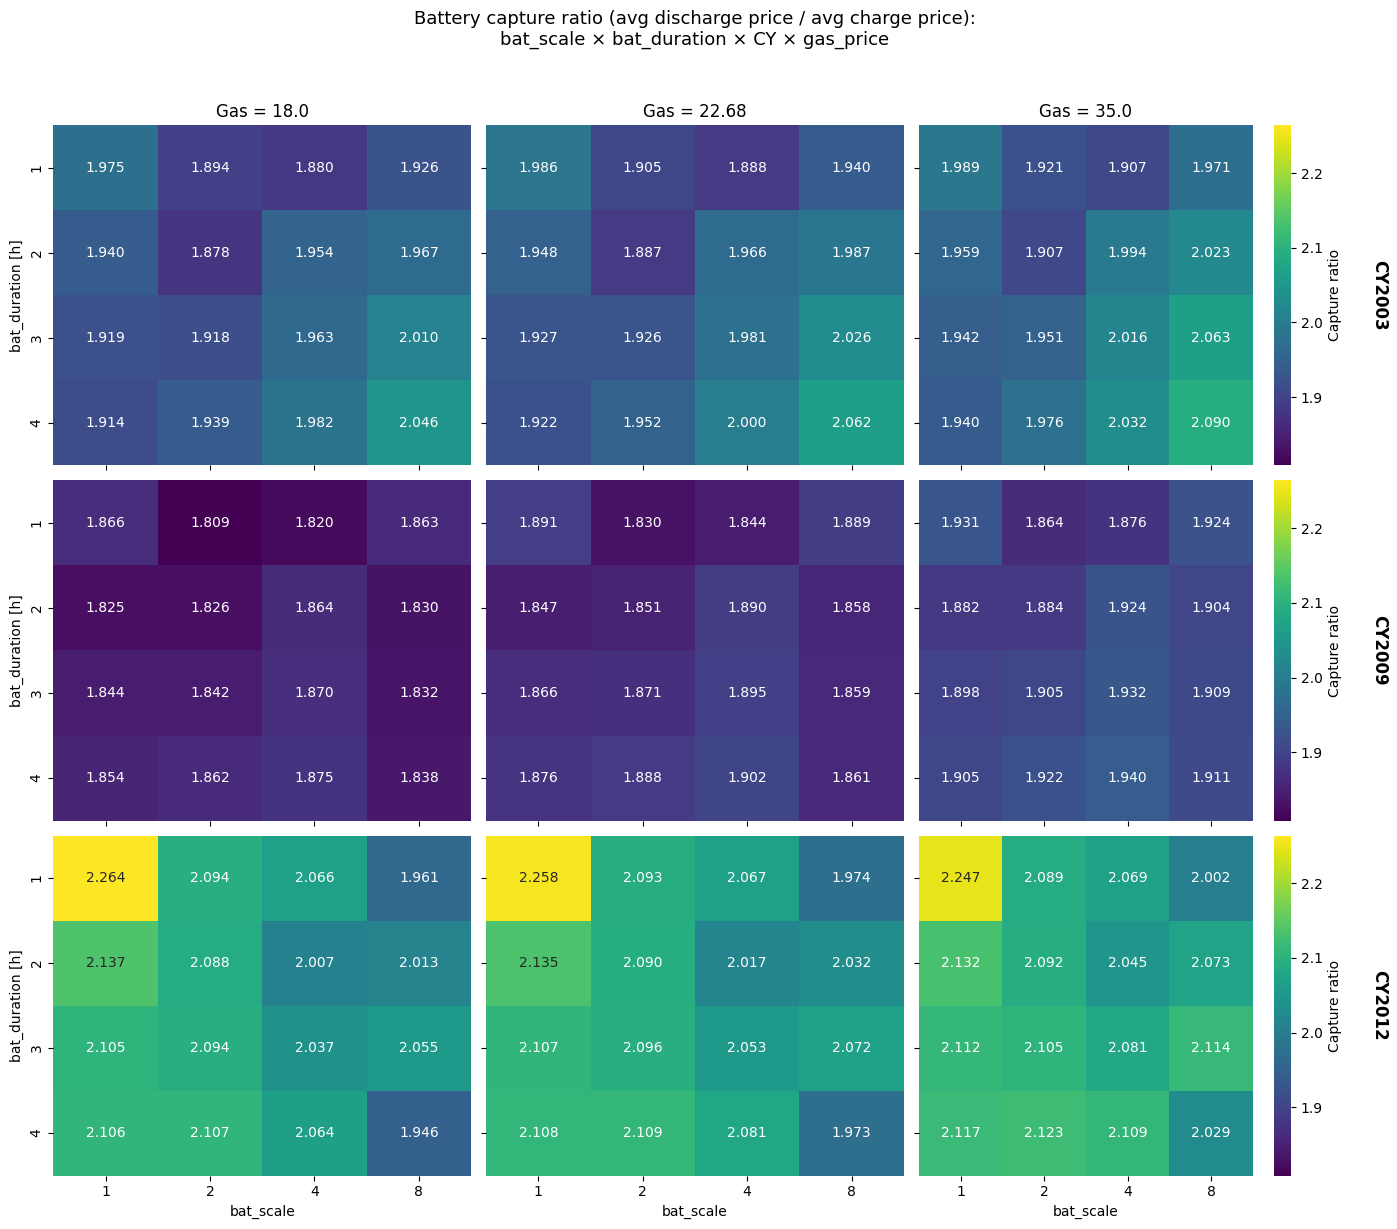

Mean capture ratio by bat_scale × bat_duration:
battery_duration      1      2      3      4
battery_scale                               
1                 2.046  1.978  1.969  1.971
2                 1.944  1.945  1.968  1.986
4                 1.935  1.962  1.980  1.998
8                 1.939  1.964  1.993  1.972

Avg discharge price: 70.4 EUR/MWh
Avg charge price: 35.6 EUR/MWh


In [22]:
# 3×3 heatmap: CY rows × gas cols, bat_scale × bat_duration inside
CYS = [2003, 2009, 2012]
GAS = [18.0, 22.68, 35.0]

fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=True, sharey=True)

all_medians = bat_df.groupby(["climate_year", "gas_price", "battery_duration", "battery_scale"])["capture_ratio"].median()
vmin, vmax = all_medians.min(), all_medians.max()

for row, cy in enumerate(CYS):
    for col, gp in enumerate(GAS):
        ax = axes[row, col]
        sub = bat_df[(bat_df["climate_year"] == cy) & (bat_df["gas_price"] == gp)]
        pivot = sub.groupby(["battery_duration", "battery_scale"])["capture_ratio"].median().reset_index()
        hm = pivot.pivot(index="battery_duration", columns="battery_scale", values="capture_ratio")

        sns.heatmap(hm, annot=True, fmt=".3f", cmap="viridis", ax=ax,
                    cbar=col == 2, vmin=vmin, vmax=vmax,
                    cbar_kws={"label": "Capture ratio"} if col == 2 else {})
        ax.set_xlabel("bat_scale" if row == 2 else "")
        ax.set_ylabel("bat_duration [h]" if col == 0 else "")

        if row == 0:
            ax.set_title(f"Gas = {gp}")
        if col == 2:
            ax.yaxis.set_label_position("right")
            ax.text(1.35, 0.5, f"CY{cy}", transform=ax.transAxes,
                    rotation=-90, va="center", fontsize=12, fontweight="bold")

plt.suptitle("Battery capture ratio (avg discharge price / avg charge price):\nbat_scale × bat_duration × CY × gas_price", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Summary stats
print("Mean capture ratio by bat_scale × bat_duration:")
print(bat_df.groupby(["battery_scale", "battery_duration"])["capture_ratio"].mean().unstack().round(3))
print(f"\nAvg discharge price: {bat_df['avg_discharge_price'].mean():.1f} EUR/MWh")
print(f"Avg charge price: {bat_df['avg_charge_price'].mean():.1f} EUR/MWh")

## Summary & Limitations

### Key Findings

**A. Peak-Offpeak Spread:**
1. The traditional peak-offpeak spread is **inverted** in the 2030 model — offpeak hours (nights + weekends) are on average 2–3 EUR/MWh more expensive than peak hours (08-20 Mon-Fri). This is driven by the solar duck curve: massive midday solar suppresses prices during peak hours, while evening ramp-up (20-23h, classified as offpeak) drives prices to 75–84 EUR/MWh.
2. Batteries deepen this inversion — bat_scale β = −0.028 (t = −4.28, p < 0.001). More batteries charge during cheap solar peak and discharge during expensive evening offpeak.
3. Gas price is the strongest predictor of spread (β = −0.062, t = −22.04, p < 0.001) — higher gas amplifies the offpeak premium as gas-fired peakers set evening prices.
4. bat_duration has no significant effect on spread (β = +0.041, t = 1.75, ns).
5. Overall model R² = 0.752 — spread is well-explained by the scenario parameters.

**B. Capture Rates:**
6. Solar capture rate increases with bat_scale (from ~0.60 to ~0.72) — batteries absorb midday surplus, reducing price cannibalization of solar generation. Effect is strongest in CY2012 (cold year with higher demand).
7. Battery capture ratio (avg discharge price / avg charge price) remains well above 1.0 across all scenarios (range 1.8–2.3). Batteries discharge at ~70 EUR/MWh and charge at ~36 EUR/MWh on average. **Important caveat:** these ratios represent an upper bound due to the LP model's perfect foresight — real-world battery arbitrage ratios are typically 1.2–1.5 (Staffell & Rustomji 2016). The comparative effect across scenarios (how ratio changes with bat_scale, gas_price, etc.) remains valid.
8. Capture ratio slightly decreases with bat_scale (e.g. 2.05 → 1.94 at 1h duration) — more batteries compress the price spread they exploit, but the effect is modest.

### Synthesis

Batteries reshape the temporal structure of electricity prices:
- They deepen the **inverted peak-offpeak spread** caused by solar penetration (traditional peak is now cheaper than offpeak)
- They lift **solar capture rates** by ~20% (reducing price cannibalization)
- They maintain strong **arbitrage value** even at 8× capacity scaling, though with modest self-cannibalization

### Limitations

1. **LP model** — no unit commitment; real peak-offpeak dynamics involve start-up costs and ramping constraints. Perfect foresight inflates battery arbitrage revenue.
2. **Uniform battery scaling** — all zones scaled equally; real deployment is heterogeneous
3. **Fixed peak definition (08-20 Mon-Fri)** — this traditional definition is inverted in the 2030 high-solar model. The actual price peak occurs at 17-21h. Results should be interpreted as "traditional peak block vs offpeak block" rather than "expensive vs cheap hours"
4. **Capture rate is aggregate** — per-zone capture rates may differ significantly from the EU-wide figures